# Power Analysis for Confirmatory Factor Analysis: A Practical Tutorial

Analytical and Simulation-Based Approaches

Pablo Rogers [](https://orcid.org/0000-0002-0093-3834) (Universidade Federal de Uberlândia)  
September 24, 2026

This tutorial presents a pedagogical introduction to statistical power analysis in Confirmatory Factor Analysis (CFA). Proper sample size planning requires assessing the probability of detecting overall model misfit, either through analytical methods or simulation-based approaches. Standard analytical tools rely on asymptotic normal theory, which can break down under non-normality or missing data. This tutorial demonstrates both strategies — analytical (using semPower with lavaan syntax) and Monte Carlo simulation (using simsem) — side by side, using the WHOQOL-BREF four-factor model as a unifying case study. We illustrate how simulation complements analytical calculations by enabling researchers to evaluate parameter-level power, coverage, and relative bias under realistic scenarios involving model misspecification, missing data, and non-normal continuous indicators. We argue that analytical methods provide a fast and theoretically grounded starting point for sample size planning, while simulation-based approaches allow those conclusions to be stress-tested against the specific population structure, misspecification form, and data conditions of the study at hand.

In [ ]:
# Note: The underlying objects and analytical calculations are defined and
# documented in their respective dedicated .qmd files. They are sourced and
# computed here, in this setup chunk, to support inline R expressions (`r ...`)
# throughout the manuscript. In the other files, we have the objects and
# calculations with comments.

source(here::here("Scripts", "DataAppendixScripts", "models.R"))
source(here::here("Scripts", "DataAppendixScripts", "helpers.R"))

df_model <- semPower.getDf(analyzemodel)-4

ap_rmsea <- semPower::semPower.aPriori(
  effect         = 0.05,
  effect.measure = "RMSEA",
  alpha          = ALPHA,
  power          = POWER,
  df             = df_model,
  p              = P
)

ap_popmodel <- semPower::semPower.powerLav(
  type       = "a-priori",
  alpha      = ALPHA,
  power      = POWER,
  modelPop   = h1model,
  modelH0    = analyzemodel,
  lavOptions = list(std.lv = TRUE)
)

cache_dir <- here("Data", "IntermediateData")

popmodel_ideal   <- readRDS(file.path(cache_dir, "popmodel_ideal.rds"))
h1model_ideal    <- readRDS(file.path(cache_dir, "h1model_ideal.rds"))
naivemodel_ideal <- readRDS(file.path(cache_dir, "naivemodel_ideal.rds"))
optmodel_ideal   <- readRDS(file.path(cache_dir, "optmodel_ideal.rds"))

power_ideal  <- as.list(getPowerFit(
  h1model_ideal, nullObject = popmodel_ideal,
  alpha = ALPHA, nVal = 231, usedFit = FITS
))
cutoff_ideal <- as.list(getCutoff(
  popmodel_ideal, alpha = ALPHA, nVal = 231, usedFit = FITS
))

n_h1    <- as.list(findPower(getPower(h1model_ideal,    alpha = ALPHA), "N", 0.80))
n_naive <- as.list(findPower(getPower(naivemodel_ideal, alpha = ALPHA), "N", 0.80))
n_opt   <- as.list(findPower(getPower(optmodel_ideal,   alpha = ALPHA), "N", 0.80))

popmodel_miss    <- readRDS(file.path(cache_dir, "popmodel_miss.rds"))
h1model_miss     <- readRDS(file.path(cache_dir, "h1model_miss.rds"))

power_miss <- getPowerFit(
  h1model_miss, nullObject = popmodel_miss,
  alpha = ALPHA, nVal = 359, usedFit = FITS
)
cutoff_miss <- getCutoff(
  popmodel_miss, alpha = ALPHA, nVal = 359, usedFit = FITS
)
power_cutoff_miss <- rbind(
  "Power"  = as.numeric(power_miss),
  "Cutoff" = as.numeric(cutoff_miss[1, ])
)
colnames(power_cutoff_miss) <- toupper(names(power_miss))

popmodel_nnorm   <- readRDS(file.path(cache_dir, "popmodel_nnorm.rds"))
h1model_nnorm    <- readRDS(file.path(cache_dir, "h1model_nnorm.rds"))

power_nnorm <- getPowerFit(
  h1model_nnorm, nullObject = popmodel_nnorm,
  alpha = ALPHA, nVal = 228, usedFit = FITS
)
cutoff_nnorm <- getCutoff(
  popmodel_nnorm, alpha = ALPHA, nVal = 228, usedFit = FITS
)
power_cutoff_nnorm <- rbind(
  "Power"  = as.numeric(power_nnorm),
  "Cutoff" = as.numeric(cutoff_nnorm[1, ])
)
colnames(power_cutoff_nnorm) <- toupper(names(power_nnorm))

url_data <- "https://data.mendeley.com/datasets/rdky78bk8r/2/files/b58a7054-4978-4239-81db-00f9efd86e44/WHOQOL_Data.dat"
realdata <- read.table(url_data)

url_labels <- "https://data.mendeley.com/datasets/rdky78bk8r/2/files/ae2a5c01-2fc2-43e5-b31c-8db8cc5bff8a/WHOQOL_Labels.txt"
column_labels <- read.table(url_labels)
column_labels <- column_labels$V1
names(realdata) <- gsub("_[FPSA]$", "", column_labels)
n_real <- nrow(realdata)

fit_real <- lavaan::cfa(
  analyzemodel,
  data      = realdata,
  estimator = "mlr",
  std.lv = TRUE
)

ph_rmsea <- semPower::semPower.postHoc(
  effect         = 0.05,
  effect.measure = "RMSEA",
  alpha          = ALPHA,
  N              = n_real,
  df             = df_model,
  p              = P
)

ph_realmodel <- semPower::semPower.powerLav(
  type       = "post-hoc",
  alpha      = ALPHA,
  N          = n_real,
  modelPop   = h1model,
  modelH0    = fit_real,
  lavOptions = list(std.lv = TRUE)
)

## 1 Introduction

Statistical power in CFA is the probability of correctly rejecting a misspecified model — or of detecting a parameter of interest when it is truly non-zero in the population ([MacCallum et al., 1996](#ref-maccallum1996)). Despite its importance, power is rarely reported in applied CFA work: researchers frequently fall back on arbitrary rules of thumb linking required sample size to the number of observed variables or estimated parameters, rather than conducting formal prospective calculations ([Aguirre-Urreta et al., 2024](#ref-aguirre-urreta2024); [Wolf et al., 2013](#ref-wolf2013)).

Two main paradigms address power analysis in CFA:

1.  **Analytical methods**: Rely on the non-central $\chi^2$ distribution to determine the sample size required for detecting global or local model misfit, typically quantified through the RMSEA ([Jak et al., 2021](#ref-jak2021); [MacCallum et al., 1996](#ref-maccallum1996)).
2.  **Simulation-based methods**: Use Monte Carlo data generation to estimate power, bias, and coverage for specific parameters or overall fit indices across varying sample sizes, without relying on the asymptotic assumptions that constrain analytical solutions ([Muthén & Muthén, 2002](#ref-muthen2002a); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

This document provides a comprehensive tutorial covering both paradigms: analytical power analysis using the `semPower` package, and Monte Carlo simulation using the `simsem` package ([Moshagen & Bader, 2024](#ref-moshagen2024); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

> **Reproducibility Note**
>
> For local development and computational convenience, simulations in this tutorial use 1,500 replications. Production-quality applied research should increase this to 5,000 or more. Results throughout this tutorial therefore carry more sampling variability than would be expected in a final study. All analytical and simulation parameters are centrally defined in `helpers.R` and `models.R` in `Scripts/DataAppendixScripts`.

## 2 The Running Example: WHOQOL-BREF Population CFA Model

All power analyses in this tutorial are anchored in the World Health Organization Quality of Life-BREF (WHOQOL-BREF) four-factor measurement model ([Lin & Yao, 2022](#ref-lin2022); [<span class="nocase">Mosqueira Taipe et al.</span>, 2026](#ref-mosqueirataipe2026)). Meaningful power analysis requires an explicit population model — a formal representation of the “true” covariance structure from which data are presumed to be generated ([Feng & Hancock, 2023](#ref-feng2023)). By grounding this model in meta-analytic evidence rather than in arbitrary parameter choices, we ensure that sample size targets reflect realistic measurement conditions ([Lin & Yao, 2022](#ref-lin2022); [<span class="nocase">Mosqueira Taipe et al.</span>, 2026](#ref-mosqueirataipe2026)).

We specify four population variants to support sensitivity analyses:

1.  **Meta-analytic** (`popmodel`): Loadings and residual variances matching the pooled estimates from Lin & Yao ([2022](#ref-lin2022)).
2.  **Naive** (`naivemodel`): A pessimistic baseline derived from the lowest reported reliability values per domain ([<span class="nocase">Mosqueira Taipe et al.</span>, 2026](#ref-mosqueirataipe2026)).
3.  **Optimistic** (`optmodel`): A best-case scenario derived from the highest reported reliability values per domain ([<span class="nocase">Mosqueira Taipe et al.</span>, 2026](#ref-mosqueirataipe2026)).
4.  **Misspecification** (`h1model`): A cross-loading model representing the alternative hypothesis $H_1$, with three additional cross-loadings based on the meta-EFA results of Lin & Yao ([2022](#ref-lin2022)).

### 2.1 Population model

The primary population model (`popmodel`) operationalizes a meta-analytic scenario based on Lin & Yao ([2022](#ref-lin2022)), whose pooled EFA estimates across 16 international studies provide the factor loadings ($\lambda$). Key features of this model are:

- **Interfactor correlations ($\phi$)**: Fixed at $0.20$, a conservative midpoint of the reported range $0.08$–$0.31$ ([Lin & Yao, 2022](#ref-lin2022)).
- **Residual covariance**: Items $Q3$ and $Q4$ share a residual covariance ($r_{Q3, Q4 \mid \text{physical}} = 0.30$), preserving the subfactor signal identified in the five-factor EFA solution ([Lin & Yao, 2022](#ref-lin2022)).
- **Factor structure**: Item $Q8$ is retained in the Environmental domain despite loading more strongly on the Psychological domain in the meta-EFA. This constitutes the null hypothesis ($H_0$) version of the population, strictly maintaining the original four-factor structure without cross-loadings.

``` python
plot_color(popmodel) # See plot_color() function in helpers.R for details.
```

<figure id="fig-diagram-popmodel">
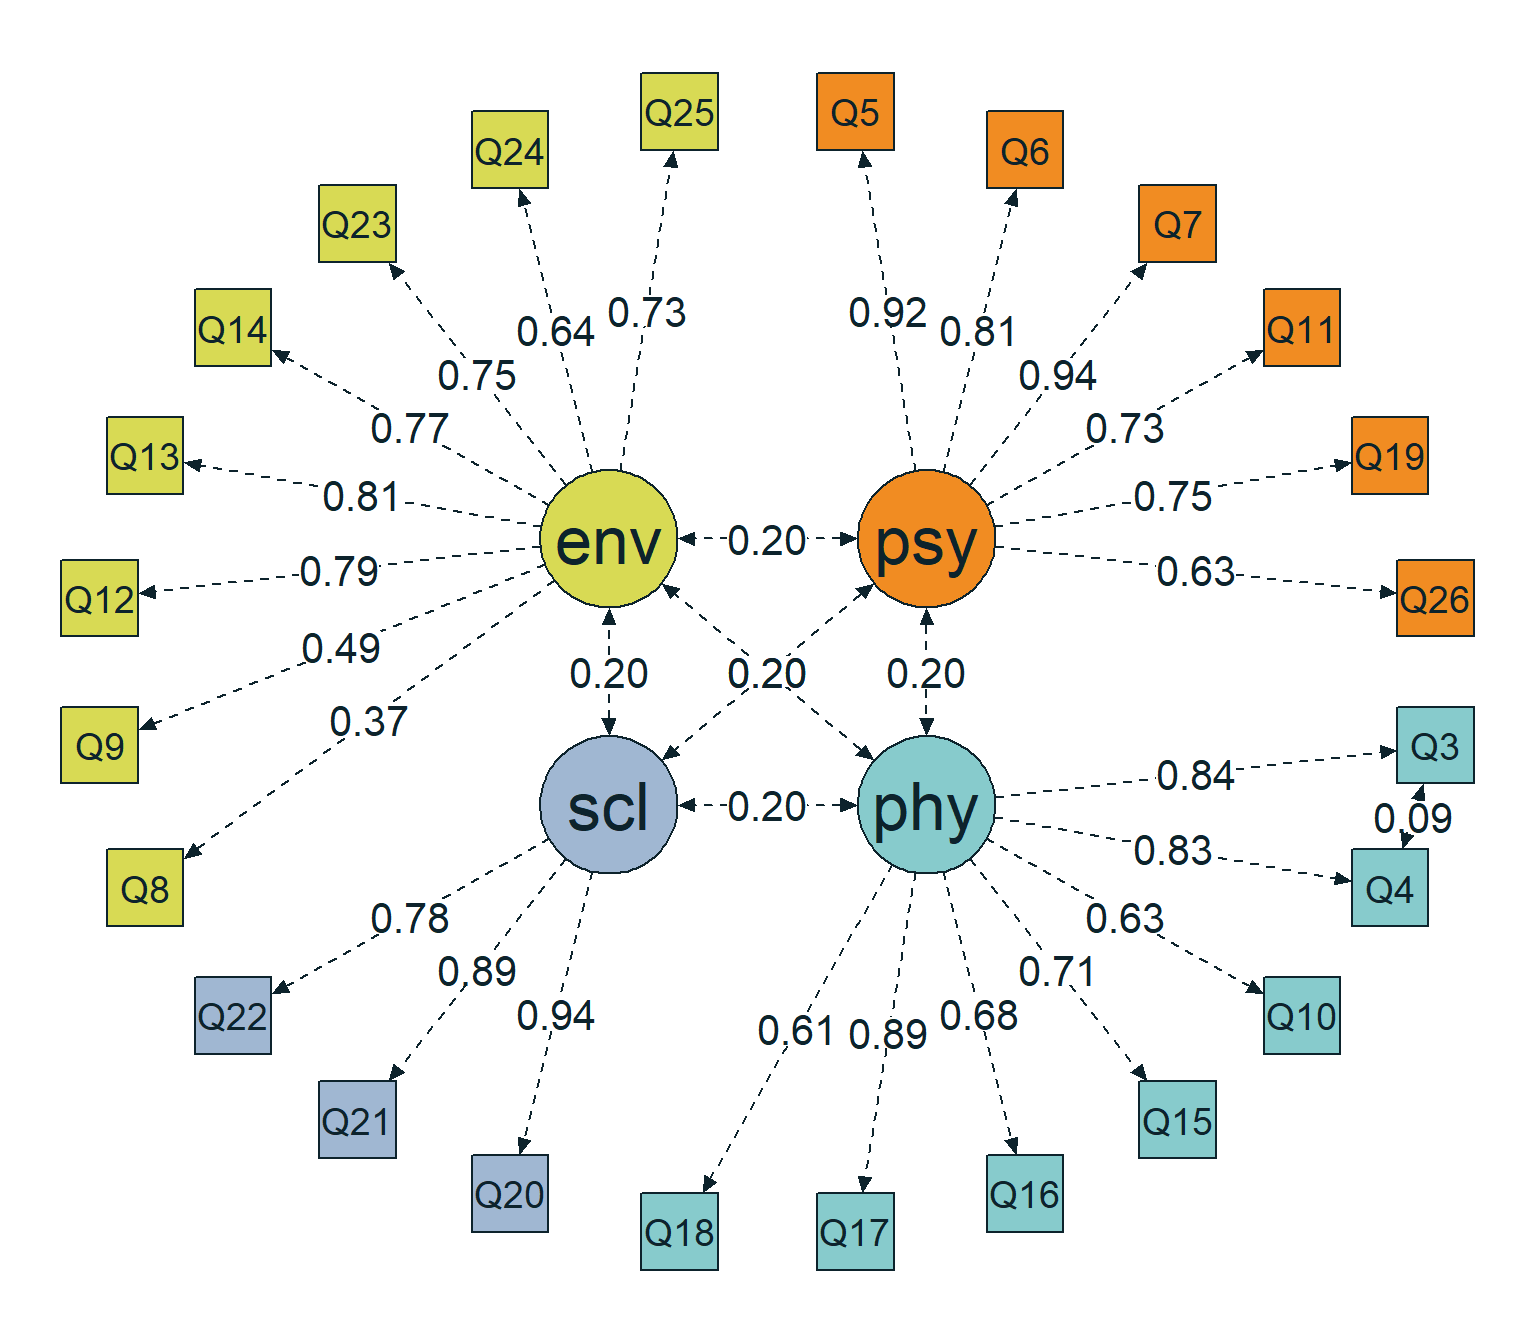
<figcaption>Figure 1: Path diagram of the popmodel</figcaption>
</figure>

### 2.2 Naive model

The naive model provides an empirically grounded pessimistic scenario. Factor loadings are derived via the Spearman-Brown prediction formula from the lowest Cronbach’s $\alpha$ values identified in the literature ([<span class="nocase">Mosqueira Taipe et al.</span>, 2026](#ref-mosqueirataipe2026)), yielding conservative parameter estimates that push sample size requirements upward:

- **Approach**: Assuming equal loadings within each domain, $\lambda = \sqrt{\alpha / (k - \alpha(k-1))}$ and $\theta = 1 - \lambda^2$.
- **Alpha sources**: Lowest domain alphas from a single study identified in the systematic review by <span class="nocase">Mosqueira Taipe et al.</span> ([2026](#ref-mosqueirataipe2026)) (Physical $\alpha = 0.672$; Psychological $\alpha = 0.704$; Social $\alpha = 0.630$; Environmental $\alpha = 0.709$), all within the $M - 1SD$ range reported by Lin & Yao ([2022](#ref-lin2022)).
- **Interfactor correlations ($\phi$)**: Fixed at $0.30$ (the upper bound from Lin & Yao ([2022](#ref-lin2022))), making factors harder to distinguish and yielding a deliberately conservative power estimate.
- **Derived parameters**: Physical ($\lambda = 0.4758$, $\theta = 0.7736$); Psychological ($\lambda = 0.5328$, $\theta = 0.7161$); Social ($\lambda = 0.6017$, $\theta = 0.6379$); Environmental ($\lambda = 0.4832$, $\theta = 0.7665$). The residual covariance between $Q3$ and $Q4$ is adjusted to $0.2321$.

``` python
plot_color(naivemodel) # See plot_color() function in helpers.R for details.
```

<figure id="fig-diagram-naivemodel">
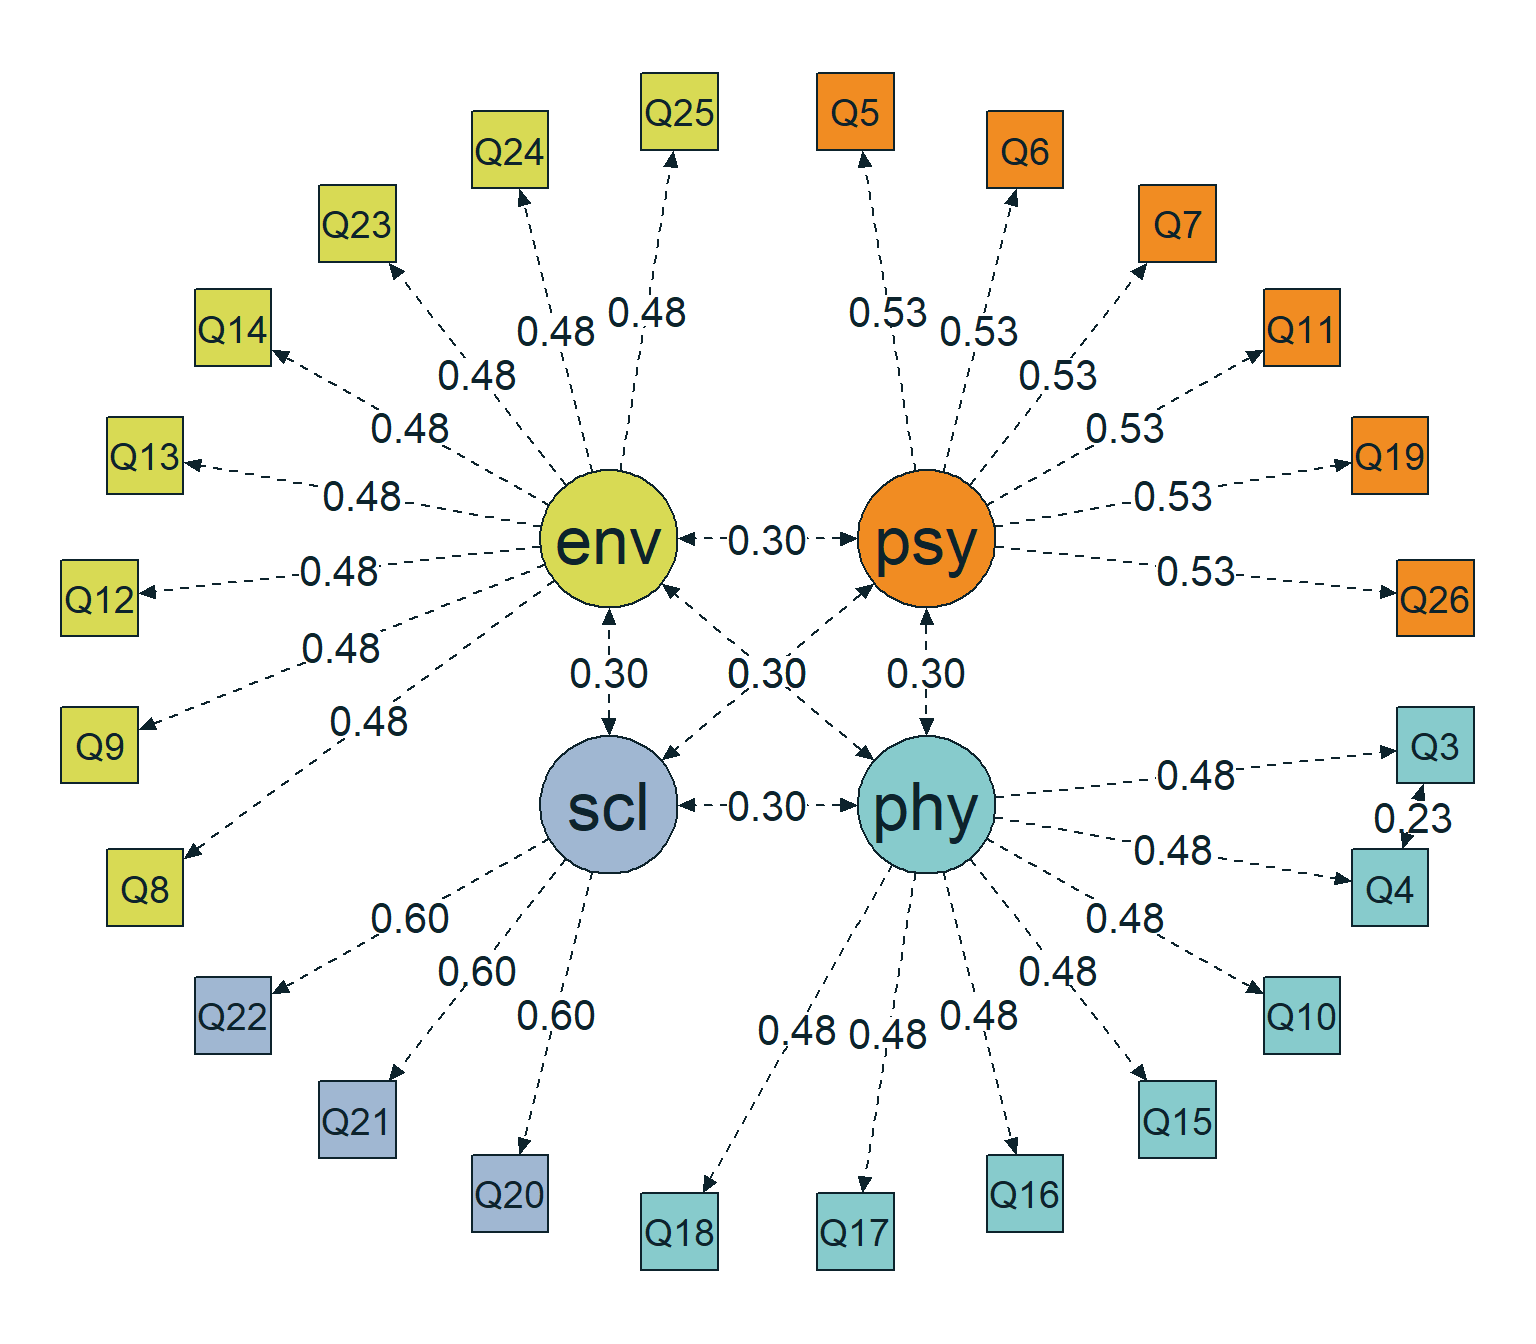
<figcaption>Figure 2: Path diagram of the naivemodel</figcaption>
</figure>

### 2.3 Optimistic model

The optimistic model applies the same Spearman-Brown derivation but draws on the highest observed Cronbach’s $\alpha$ values per domain, producing stronger loadings and lower residual variances relative to the naive model ([<span class="nocase">Mosqueira Taipe et al.</span>, 2026](#ref-mosqueirataipe2026)):

- **Alpha sources**: Maximum domain alphas from the literature ([<span class="nocase">Mosqueira Taipe et al.</span>, 2026](#ref-mosqueirataipe2026)) (Physical $\alpha = 0.860$; Psychological $\alpha = 0.860$; Social $\alpha = 0.810$; Environmental $\alpha = 0.849$), all confirmed within the $M + 1SD$ range from Lin & Yao ([2022](#ref-lin2022)).
- **Interfactor correlations ($\phi$)**: Fixed at $0.08$ (the lower bound from Lin & Yao ([2022](#ref-lin2022))), so that factors are well distinguished and sample size requirements are reduced.
- **Derived parameters**: Physical ($\lambda = 0.6837$, $\theta = 0.5326$); Psychological ($\lambda = 0.7113$, $\theta = 0.4941$); Social ($\lambda = 0.7661$, $\theta = 0.4130$); Environmental ($\lambda = 0.6424$, $\theta = 0.5873$). The residual covariance between $Q3$ and $Q4$ is adjusted to $0.1598$.

``` python
plot_color(optmodel) # See plot_color() function in helpers.R for details.
```

<figure id="fig-diagram-optmodel">
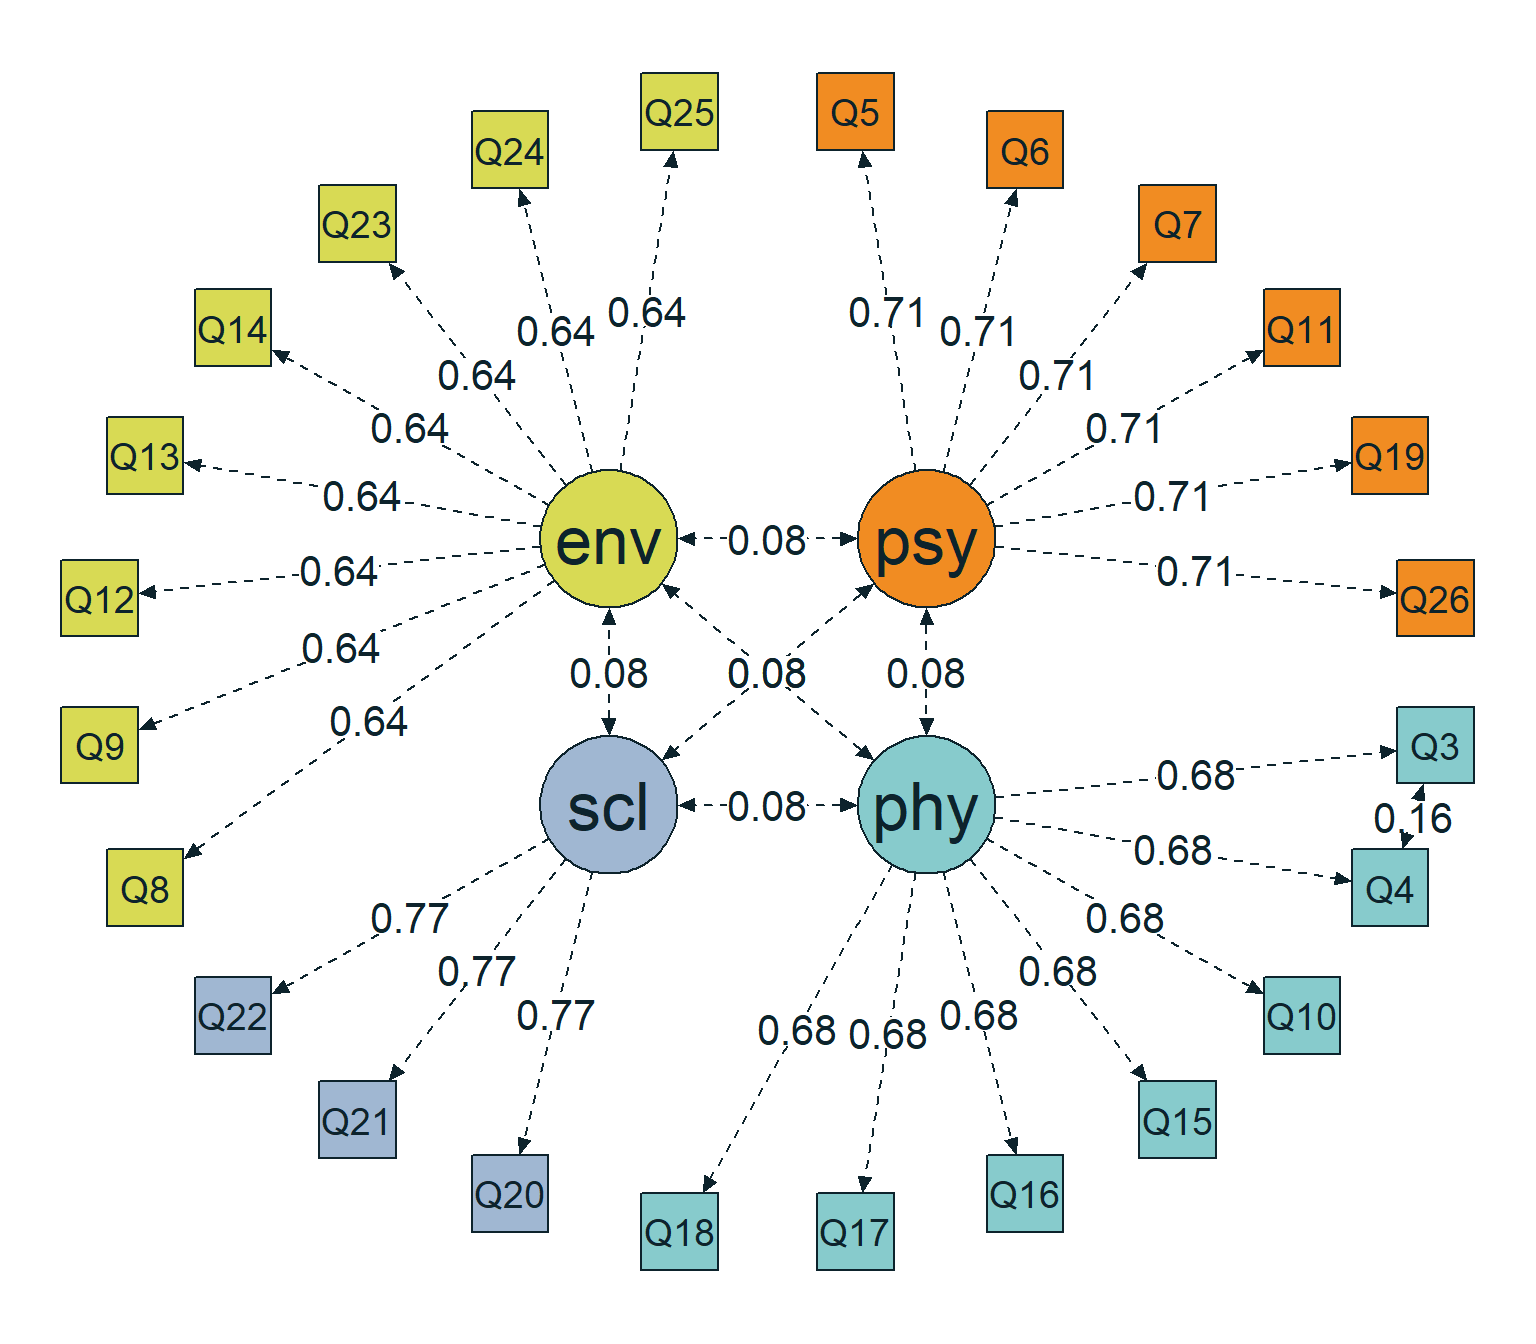
<figcaption>Figure 3: Path diagram of the optmodel</figcaption>
</figure>

### 2.4 Misspecification model

This model defines the alternative hypothesis ($H_1$): a cross-loading variant of the four-factor structure in which three empirically motivated cross-loadings are added based on the meta-EFA results of Lin & Yao ([2022](#ref-lin2022)) and the systematic review evidence in <span class="nocase">Mosqueira Taipe et al.</span> ([2026](#ref-mosqueirataipe2026)):

- **Cross-loading 1**: Item $Q8$ on the Psychological factor ($\lambda = 0.55$). This item showed the highest betweenness centrality ($40.50$) and was assigned to the Psychological factor in 9 of 16 studies ([Lin & Yao, 2022](#ref-lin2022)).
- **Cross-loading 2**: Item $Q9$ on the Psychological factor ($\lambda = 0.21$), identified as a secondary loading in the five-factor EFA solution.
- **Cross-loading 3**: Item $Q15$ on the Environmental factor ($\lambda = 0.24$). “Mobility” conceptually bridges physical ability and environmental access, and this item showed the second-highest betweenness centrality ($36.50$) ([Lin & Yao, 2022](#ref-lin2022)).

Residual variances for cross-loaded items were recalculated to preserve total item variance: $\theta = 1 - \lambda_{\text{primary}}^2 - \lambda_{\text{secondary}}^2 - 2\lambda_{\text{primary}}\lambda_{\text{secondary}}\phi$, where $\phi = 0.20$.

``` python
plot_color(h1model) # See plot_color() function in helpers.R for details.
```

<figure id="fig-diagram-h1model">
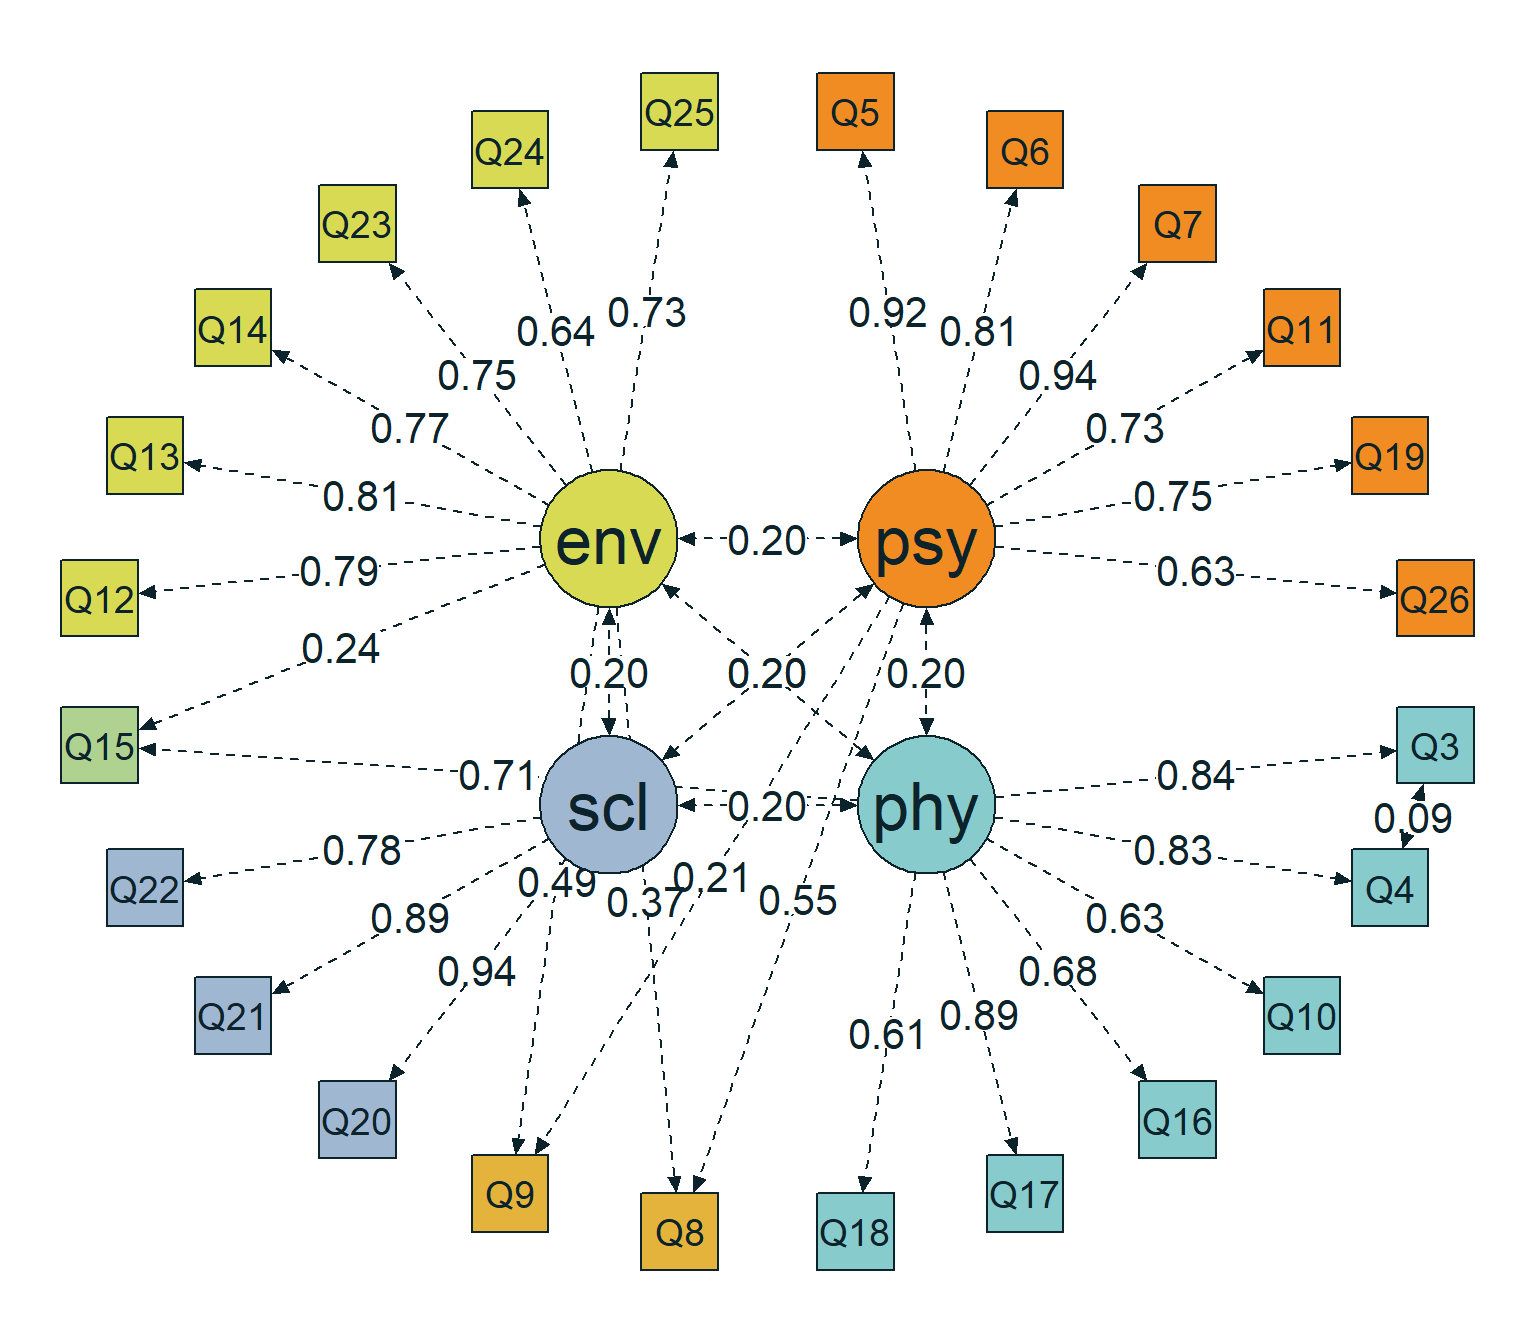
<figcaption>Figure 4: Path diagram of the h1model</figcaption>
</figure>

### 2.5 Summary of population models

<a href="#tbl-pop-summary" class="quarto-xref">Table 1</a> presents all parameters of the four population models. <a href="#tbl-pop-comparison" class="quarto-xref">Table 2</a> summarizes key features across models — minimum and maximum factor loadings, mean loading, modal interfactor correlation, minimum and maximum residual variances, and the residual correlation between $Q3$ and $Q4$ — to facilitate direct comparison.

``` python
# See popmodels_parameters.csv file in InputData folder.
csv <- read.csv(
  here("Data", "InputData", "popmodels_parameters.csv"),
  quote = "",
  check.names = FALSE,
  stringsAsFactors = FALSE
)

# Remove quotes from the column names
names(csv) <- gsub('"', '', names(csv))

# Transpose the data frame to have parameters as rows and models as columns
param_transp <- as.data.frame(t(csv[-1]), stringsAsFactors = FALSE)
names(param_transp) <- csv[[1]]
param_transp <- cbind(parameters = names(csv)[-1], param_transp)
row.names(param_transp) <- NULL

# Escape ~~ for Pandoc (prevents strikethrough in HTML); keep param_transp clean.
display <- param_transp
display$parameters <- gsub("~~", "\\~\\~", display$parameters, fixed = TRUE)

# Display the parameters table
display |>
  kable(
    digits = 4,
    align = "lcccc",
    booktabs = TRUE,
    escape = FALSE,
    col.names = c("parameters", "popmodel", "naivemodel", "optmodel", "h1model")
  )
```

| parameters                | popmodel | naivemodel | optmodel | h1model |
|:--------------------------|:--------:|:----------:|:--------:|:-------:|
| psycho=~Q5                |  0.9200  |   0.5328   |  0.7113  | 0.9200  |
| psycho=~Q6                |  0.8100  |   0.5328   |  0.7113  | 0.8100  |
| psycho=~Q7                |  0.9400  |   0.5328   |  0.7113  | 0.9400  |
| psycho=~Q11               |  0.7300  |   0.5328   |  0.7113  | 0.7300  |
| psycho=~Q19               |  0.7500  |   0.5328   |  0.7113  | 0.7500  |
| psycho=~Q26               |  0.6300  |   0.5328   |  0.7113  | 0.6300  |
| physical=~Q3              |  0.8400  |   0.4758   |  0.6837  | 0.8400  |
| physical=~Q4              |  0.8300  |   0.4758   |  0.6837  | 0.8300  |
| physical=~Q10             |  0.6300  |   0.4758   |  0.6837  | 0.6300  |
| physical=~Q15             |  0.7100  |   0.4758   |  0.6837  | 0.7100  |
| physical=~Q16             |  0.6800  |   0.4758   |  0.6837  | 0.6800  |
| physical=~Q17             |  0.8900  |   0.4758   |  0.6837  | 0.8900  |
| physical=~Q18             |  0.6100  |   0.4758   |  0.6837  | 0.6100  |
| social=~Q20               |  0.9400  |   0.6017   |  0.7661  | 0.9400  |
| social=~Q21               |  0.8900  |   0.6017   |  0.7661  | 0.8900  |
| social=~Q22               |  0.7800  |   0.6017   |  0.7661  | 0.7800  |
| environment=~Q8           |  0.3700  |   0.4832   |  0.6424  | 0.3700  |
| environment=~Q9           |  0.4900  |   0.4832   |  0.6424  | 0.4900  |
| environment=~Q12          |  0.7900  |   0.4832   |  0.6424  | 0.7900  |
| environment=~Q13          |  0.8100  |   0.4832   |  0.6424  | 0.8100  |
| environment=~Q14          |  0.7700  |   0.4832   |  0.6424  | 0.7700  |
| environment=~Q23          |  0.7500  |   0.4832   |  0.6424  | 0.7500  |
| environment=~Q24          |  0.6400  |   0.4832   |  0.6424  | 0.6400  |
| environment=~Q25          |  0.7300  |   0.4832   |  0.6424  | 0.7300  |
| Q3\~~Q4                   |  0.0908  |   0.2321   |  0.1598  | 0.0908  |
| psycho\~~psycho           |  1.0000  |   1.0000   |  1.0000  | 1.0000  |
| psycho\~~physical         |  0.2000  |   0.3000   |  0.0800  | 0.2000  |
| psycho\~~social           |  0.2000  |   0.3000   |  0.0800  | 0.2000  |
| psycho\~~environment      |  0.2000  |   0.3000   |  0.0800  | 0.2000  |
| physical\~~physical       |  1.0000  |   1.0000   |  1.0000  | 1.0000  |
| physical\~~social         |  0.2000  |   0.3000   |  0.0800  | 0.2000  |
| physical\~~environment    |  0.2000  |   0.3000   |  0.0800  | 0.2000  |
| social\~~social           |  1.0000  |   1.0000   |  1.0000  | 1.0000  |
| social\~~environment      |  0.2000  |   0.3000   |  0.0800  | 0.2000  |
| environment\~~environment |  1.0000  |   1.0000   |  1.0000  | 1.0000  |
| Q5\~~Q5                   |  0.1536  |   0.7161   |  0.4941  | 0.1536  |
| Q6\~~Q6                   |  0.3439  |   0.7161   |  0.4941  | 0.3439  |
| Q7\~~Q7                   |  0.1164  |   0.7161   |  0.4941  | 0.1164  |
| Q11\~~Q11                 |  0.4671  |   0.7161   |  0.4941  | 0.4671  |
| Q19\~~Q19                 |  0.4375  |   0.7161   |  0.4941  | 0.4375  |
| Q26\~~Q26                 |  0.6031  |   0.7161   |  0.4941  | 0.6031  |
| Q3\~~Q3                   |  0.2944  |   0.7736   |  0.5326  | 0.2944  |
| Q4\~~Q4                   |  0.3111  |   0.7736   |  0.5326  | 0.3111  |
| Q10\~~Q10                 |  0.6031  |   0.7736   |  0.5326  | 0.6031  |
| Q15\~~Q15                 |  0.4959  |   0.7736   |  0.5326  | 0.3701  |
| Q16\~~Q16                 |  0.5376  |   0.7736   |  0.5326  | 0.5376  |
| Q17\~~Q17                 |  0.2079  |   0.7736   |  0.5326  | 0.2079  |
| Q18\~~Q18                 |  0.6279  |   0.7736   |  0.5326  | 0.6279  |
| Q20\~~Q20                 |  0.1164  |   0.6379   |  0.4130  | 0.1164  |
| Q21\~~Q21                 |  0.2079  |   0.6379   |  0.4130  | 0.2079  |
| Q22\~~Q22                 |  0.3916  |   0.6379   |  0.4130  | 0.3916  |
| Q8\~~Q8                   |  0.8631  |   0.7665   |  0.5873  | 0.4792  |
| Q9\~~Q9                   |  0.7599  |   0.7665   |  0.5873  | 0.6746  |
| Q12\~~Q12                 |  0.3759  |   0.7665   |  0.5873  | 0.3759  |
| Q13\~~Q13                 |  0.3439  |   0.7665   |  0.5873  | 0.3439  |
| Q14\~~Q14                 |  0.4071  |   0.7665   |  0.5873  | 0.4071  |
| Q23\~~Q23                 |  0.4375  |   0.7665   |  0.5873  | 0.4375  |
| Q24\~~Q24                 |  0.5904  |   0.7665   |  0.5873  | 0.5904  |
| Q25\~~Q25                 |  0.4671  |   0.7665   |  0.5873  | 0.4671  |
| psycho=~Q8                |    NA    |     NA     |    NA    | 0.5500  |
| psycho=~Q9                |    NA    |     NA     |    NA    | 0.2100  |
| environment=~Q15          |    NA    |     NA     |    NA    | 0.2400  |

Table 1: Summary of population models used for sensitivity analysis

``` python
# Helper: return the most frequent non-missing value.
Mode <- function(x) {
  ux <- unique(na.omit(x))
  ux[which.max(tabulate(match(na.omit(x), ux)))]
}

# Extract key summary metrics for one model specification.
get_metrics <- function(model_name) {
  vals <- param_transp[[model_name]]
  params <- param_transp$parameters

  loadings <- as.numeric(vals[grepl("=~", params, fixed = TRUE)])
  is_cov <- grepl("~~", params, fixed = TRUE) & !grepl("^Q", params)
  lr <- strsplit(params[is_cov], "~~", fixed = TRUE)
  factor_cors <- as.numeric(vals[is_cov][vapply(lr, \(x) x[1] != x[2], logical(1))])
  is_res <- grepl("^Q.+~~Q.+$", params)
  lr_r <- strsplit(params[is_res], "~~", fixed = TRUE)
  residuals <- as.numeric(vals[is_res][vapply(lr_r, \(x) x[1] == x[2], logical(1))])
  q3q4 <- as.numeric(vals[params == "Q3~~Q4"])

  sprintf("%.2f", c(
    min(loadings, na.rm = TRUE), max(loadings, na.rm = TRUE),
    mean(loadings, na.rm = TRUE), Mode(factor_cors),
    min(residuals, na.rm = TRUE), max(residuals, na.rm = TRUE), q3q4
  ))
}

# Build and transpose the summary table (metrics × models).
models <- c(popmodel = "Meta-analytic (popmodel)",
            naivemodel = "Naive (naivemodel)",
            optmodel = "Optimistic (optmodel)",
            h1model = "H1 (h1model)")
metrics <- c("Loading Min", "Loading Max", "Mean Loading",
             "Factor Correlations", "Residual Min", "Residual Max",
             "Q3\u2013Q4 Correlation")

# Build and transpose the summary table (metrics × models)
pop_summary_t <- cbind(
  data.frame(Metric = metrics),
  setNames(data.frame(sapply(names(models), get_metrics)), models)
)

# Display the metrics table
kable(pop_summary_t, align = "lcccc", row.names = FALSE)
```

| Metric | Meta-analytic (popmodel) | Naive (naivemodel) | Optimistic (optmodel) | H1 (h1model) |
|:-------------|:---------------:|:------------:|:-------------:|:----------:|
| Loading Min | 0.37 | 0.48 | 0.64 | 0.21 |
| Loading Max | 0.94 | 0.60 | 0.77 | 0.94 |
| Mean Loading | 0.75 | 0.51 | 0.69 | 0.70 |
| Factor Correlations | 0.20 | 0.30 | 0.08 | 0.20 |
| Residual Min | 0.12 | 0.64 | 0.41 | 0.12 |
| Residual Max | 0.86 | 0.77 | 0.59 | 0.67 |
| Q3–Q4 Correlation | 0.09 | 0.23 | 0.16 | 0.09 |

Table 2: Comparison of model variants used for sensitivity analysis

### 2.6 Analysis model

The analysis model (`analyzemodel`) serves dual purposes depending on the simulation paradigm:

- **Misspecification detection**: When data are generated from the misspecification model (`h1model`), the analysis model acts as the null hypothesis ($H_0$) by omitting the three cross-loadings. Power is then the probability of correctly rejecting this under-parameterized model.
- **Parameter recovery**: When data are generated from the meta-analytic, naive, or optimistic population models, the same structure is used to estimate the four-factor model with the $Q3$–$Q4$ residual covariance, and power reflects the ability to recover individual parameters.

Key specification choices:

- **Identification**: Factor variances fixed to $1$ (marker-free scaling), allowing all first-indicator loadings to be freely estimated.
- **Residual covariance**: The $Q3$–$Q4$ covariance is freely estimated, which is both theoretically justified and empirically supported ([Lin & Yao, 2022](#ref-lin2022); [<span class="nocase">Mosqueira Taipe et al.</span>, 2026](#ref-mosqueirataipe2026)).
- **Omitted cross-loadings**: The deliberate exclusion of cross-loadings for $Q8$, $Q9$, and $Q15$ defines the misspecification that this tutorial’s main analysis is designed to detect.

``` python
plot_free(analyzemodel) # See plot_free() function in helpers.R for details.
```

<figure id="fig-diagram-analyzemodel">
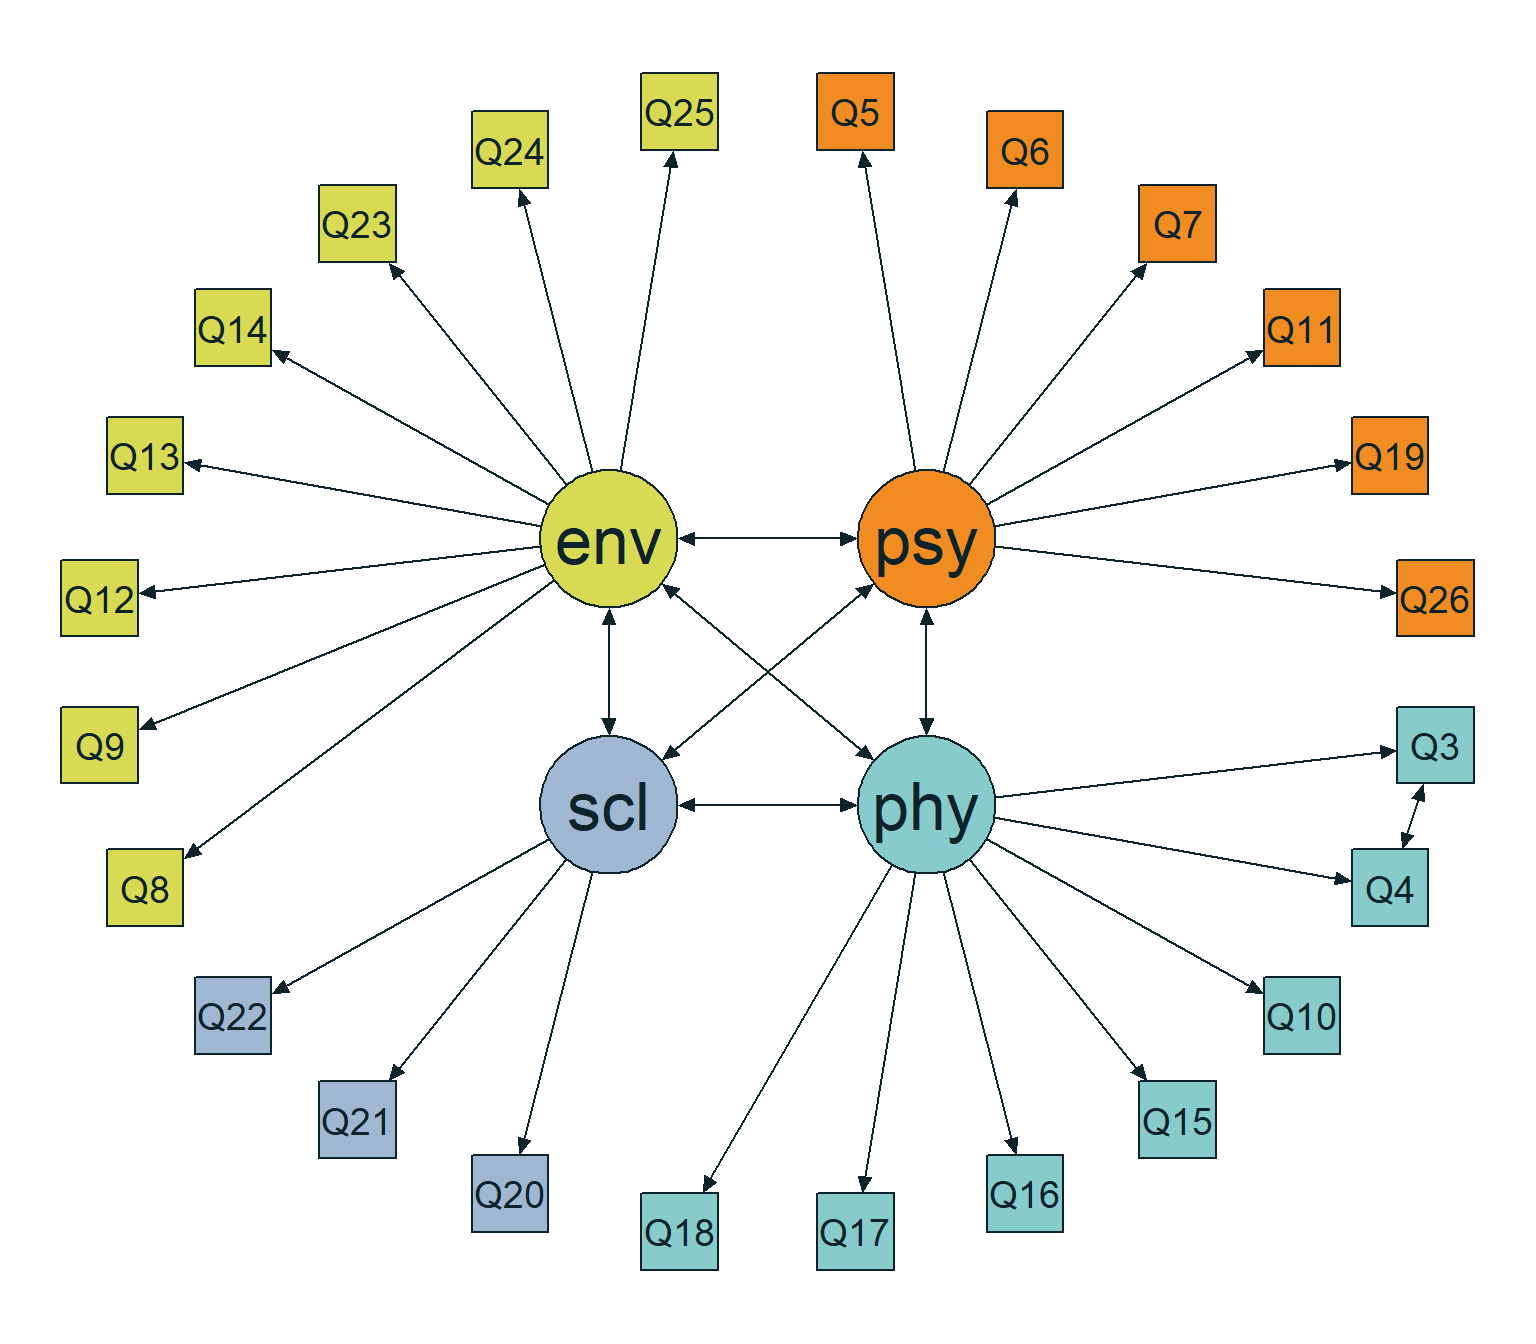
<figcaption>Figure 5: Path diagram of the analyzemodel</figcaption>
</figure>

## 3 Analytical Power Analysis

Before running any data collection, analytical power analysis answers a fundamental planning question: how large must $N$ be so that, if the model is wrong by at least a specified amount, we will reject it with acceptable probability? In SEM, the dominant analytical framework links misspecification to the non-central $\chi^2$ distribution through the noncentrality parameter $\lambda$, which scales with both $N$ and the magnitude of model discrepancy ([Jak et al., 2021](#ref-jak2021); [MacCallum et al., 1996](#ref-maccallum1996)).

### 3.1 Model Degrees of Freedom

All analytical calculations in this section depend on the model degrees of freedom ($df$) — the difference between the number of unique variances and covariances in the observed data and the number of freely estimated parameters. This quantity enters the non-central $\chi^2$ distribution directly and is therefore required before any a priori or post hoc power calculation can proceed ([Jak et al., 2021](#ref-jak2021); [Moshagen & Bader, 2024](#ref-moshagen2024)). For the hypothesized four-factor WHOQOL-BREF CFA model analyzed here (comprising 24 observed indicators, yielding $p(p + 1)/2 = 300$ non-redundant sample moments and 55 freely estimated parameters under standardized latent variables), this yields $df = 245$.

### 3.2 A Priori: How Many Observations?

#### 3.2.1 Model-free approach (RMSEA-based)

The simplest analytical strategy sets the target effect through the RMSEA, a noncentrality-based index that expresses misfit per degree of freedom and is therefore comparable across models of different complexity ([MacCallum et al., 1996](#ref-maccallum1996)). Because RMSEA is directly linked to the population minimum of the fitting function through $F_0 = \text{RMSEA}^2 \times df$, specifying a target RMSEA is sufficient to define the entire noncentrality-based framework needed for the power calculation. The approach is “model-free” in the sense that no explicit population model needs to be specified: the required sample size depends only on $\text{RMSEA}$, $\alpha$, desired power, and $df$ ([Jak et al., 2021](#ref-jak2021); [Jobst et al., 2023](#ref-jobst2023)).

This strategy is most appropriate when the objective is to plan sample size for detecting overall model misspecification in a global chi-square test of fit, rather than for testing an individual parameter restriction ([Moshagen & Bader, 2024](#ref-moshagen2024); [Wang, 2023](#ref-wang2023)).

``` python
# Formatted table extracting analytical power metrics for clean manuscript embedding
table_sempower(ap_rmsea) # See function definition in helpers.R
```

| Metric                                  |         Symbol         |   Value |
|:----------------------------------------|:----------------------:|--------:|
| Population discrepancy                  |         $F_0$          |   0.613 |
| Root mean square error of approximation |     $\text{RMSEA}$     |   0.050 |
| McDonald centrality index               |          $Mc$          |   0.736 |
| Goodness-of-fit index                   |      $\text{GFI}$      |   0.951 |
| Adjusted goodness-of-fit index          |     $\text{AGFI}$      |   0.941 |
| Degrees of freedom                      |          $df$          |     245 |
| Required sample size                    |          $N$           |     100 |
| Critical chi-square                     | $\chi^2_{\text{crit}}$ | 282.511 |
| Noncentrality parameter                 |       $\lambda$        |  60.638 |
| Significance level (alpha)              |        $\alpha$        |   0.050 |
| Type II error rate (beta)               |        $\beta$         |  0.1984 |
| Statistical power                       |      $1 - \beta$       |  0.8016 |

Table 3: Analytical a priori power parameters for RMSEA = 0.05

The analytical solution reported in <a href="#tbl-apriori-rmsea" class="quarto-xref">Table 3</a> indicates the minimum $N$ required to detect misfit of $\text{RMSEA} = 0.05$ with power $\approx 0.80$ at $\alpha = 0.05$. Note that $0.05$ refers to the misspecification level to be detected under the alternative hypothesis, not to a tolerated misfit level under the null ([Jak et al., 2021](#ref-jak2021); [MacCallum et al., 1996](#ref-maccallum1996)).

The table presents several equivalent representations of the same target effect. The value $F_0$ = 0.613 is the population minimum of the fitting function, obtained from $F_0 = df \cdot \text{RMSEA}^2$ = 245 $\cdot$ $0.05^2$. Alongside it, the summary also reports $Mc$ = 0.736, $GFI$ = 0.951, and $AGFI$ = 0.941. These are not distinct effect sizes but alternative summaries of the same degree of model misfit, expressed in the metrics used by `semPower` ([Moshagen & Bader, 2024](#ref-moshagen2024)).

The key conversion is:

$$\lambda = (N - 1)F_0 = (N - 1)\,df\,\text{RMSEA}^2$$

which translates the chosen misfit into the noncentrality parameter used to locate the alternative $\chi^2$ distribution ([Jak et al., 2021](#ref-jak2021); [MacCallum et al., 1996](#ref-maccallum1996)).

With $df$ = 245, the a priori solution is $N$ = 100. At that $N$, the noncentrality parameter is $\lambda$ = 60.638 and the critical value is $\chi^2_c$ = 282.511. The implied $\beta$ $\approx$ 0.198 corresponds to power $1 - \beta$ $\approx$ 0.802, confirming that $N$ = 100 is the minimum sample size at which the target operating characteristics are met ([Jobst et al., 2023](#ref-jobst2023)).

In <a href="#fig-apriori-rmsea" class="quarto-xref">Figure 6</a>, the solid red curve is the central $\chi^2$ under exact fit, the dashed blue curve is the noncentral $\chi^2$ under the target misspecification, and the vertical dotted line at $\chi^2$ = 282.511 is the decision threshold ([Jak et al., 2021](#ref-jak2021); [Moshagen & Bader, 2024](#ref-moshagen2024)).

``` python
# Isolated chi-square distribution plot for clean manuscript embedding
plot_sempower(ap_rmsea) # See function definition in helpers.R
```

<figure id="fig-apriori-rmsea">
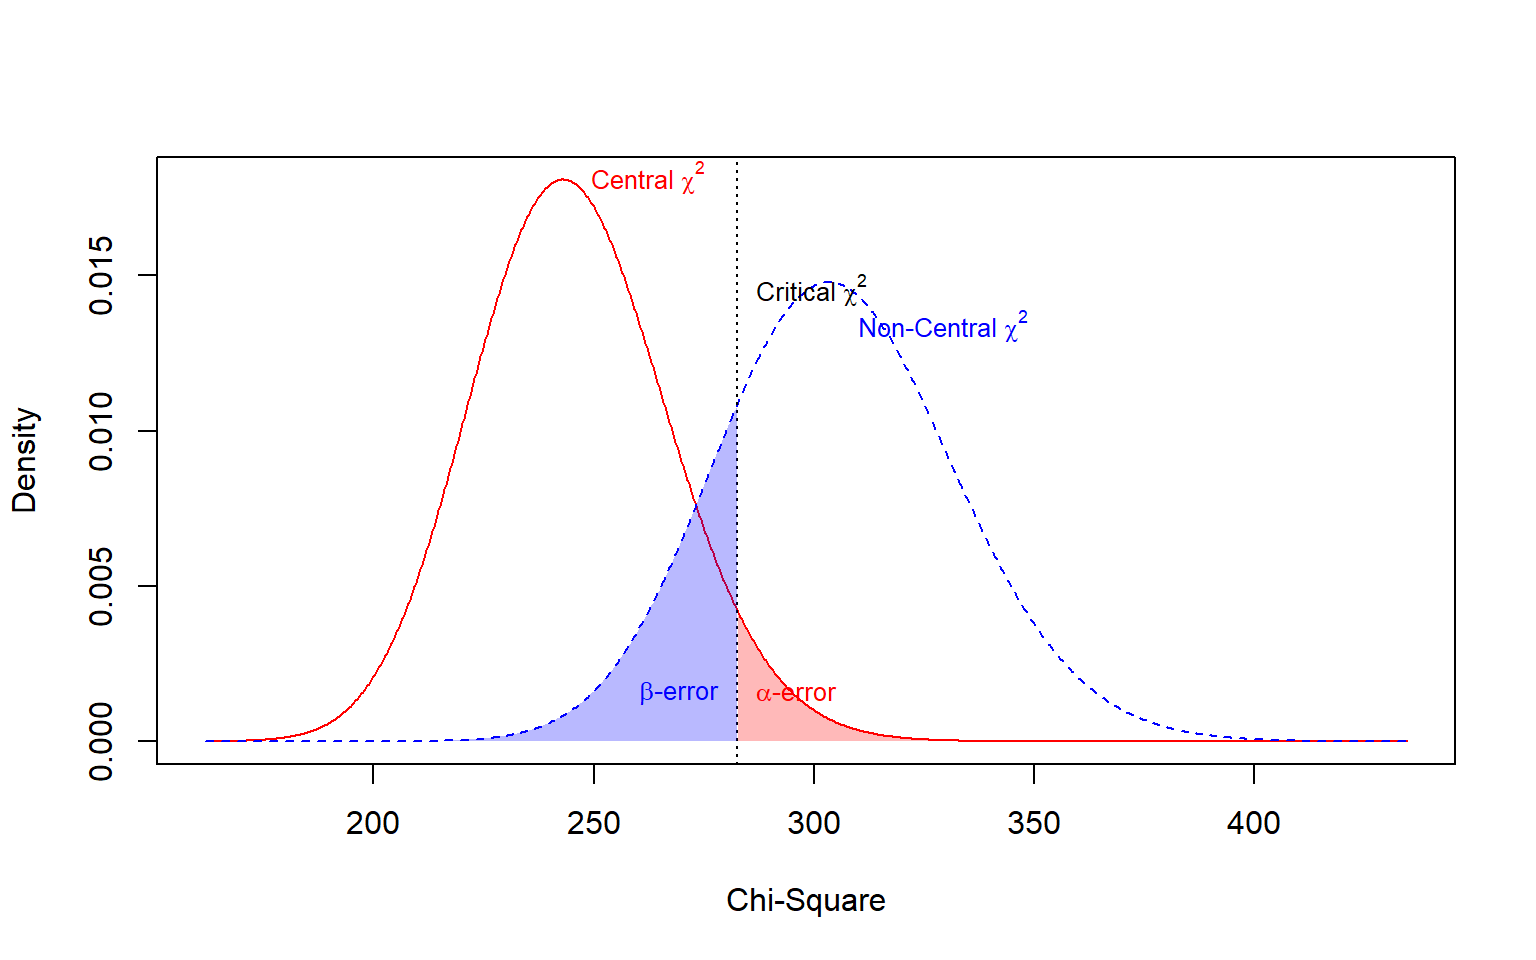
<figcaption>Figure 6: A priori power analysis for exact fit with RMSEA-based effect size</figcaption>
</figure>

#### 3.2.2 Model-based approach

When substantive theory specifies the population structure, a model-based power analysis is more informative: rather than setting misfit to a generic RMSEA value, the effect is implied by the discrepancy between an explicitly defined population model and the restricted analysis model ([Feng & Hancock, 2023](#ref-feng2023); [Wang, 2023](#ref-wang2023)). This makes the sample size estimate dependent on the hypothesized parameter configuration rather than on a conventional threshold.

`semPower.powerLav()` implements this by fitting the null model to the population-implied covariance matrix and translating the resulting discrepancy into $F_0$ and then into $\lambda = (N - 1)F_0$. When `modelH1` is omitted, the null model is evaluated against the saturated model, making the analysis a global test of fit rather than a test of any single restriction ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)). Because the effect is generated from the full model specification, any change to loadings, factor correlations, or residual variances will alter the required $N$ — an important point when conducting sensitivity analyses ([Buchberger et al., 2024](#ref-buchberger2024)).

``` python
# Formatted table extracting model-based power metrics for clean manuscript embedding
table_sempower(ap_popmodel) # See function definition in helpers.R
```

| Metric                                  |         Symbol         |   Value |
|:----------------------------------------|:----------------------:|--------:|
| Population discrepancy                  |         $F_0$          |   0.579 |
| Root mean square error of approximation |     $\text{RMSEA}$     |   0.049 |
| McDonald centrality index               |          $Mc$          |   0.749 |
| Standardized root mean square residual  |     $\text{SRMR}$      |   0.067 |
| Comparative fit index                   |      $\text{CFI}$      |   0.960 |
| Degrees of freedom                      |          $df$          |     245 |
| Required sample size                    |          $N$           |     106 |
| Critical chi-square                     | $\chi^2_{\text{crit}}$ | 282.511 |
| Noncentrality parameter                 |       $\lambda$        |  60.793 |
| Significance level (alpha)              |        $\alpha$        |   0.050 |
| Type II error rate (beta)               |        $\beta$         |  0.1968 |
| Statistical power                       |      $1 - \beta$       |  0.8032 |

Table 4: Analytical a priori power parameters for model-based approach (h1model vs analyzemodel)

The model-based analytical solution in <a href="#tbl-apriori-popmodel" class="quarto-xref">Table 4</a> reports a population discrepancy of $F_0$ = 0.579, equivalently expressed as $\text{RMSEA}$ = 0.049 and $Mc$ = 0.749. With $df$ = 245, the required sample size is $N$ = 106, and the corresponding critical chi-square is 282.511. The noncentrality parameter is $\lambda$ = 60.793, consistent with $(N - 1)F_0$ at the obtained solution. The error rates are $\alpha$ = 0.05, $\beta$ = 0.197, and power = 0.803, confirming that the design conditions are met at $N$ = 106. The corresponding distribution curves are displayed in <a href="#fig-apriori-popmodel" class="quarto-xref">Figure 7</a>:

``` python
# Isolated chi-square distribution plot for clean manuscript embedding
plot_sempower(ap_popmodel) # See function definition in helpers.R
```

<figure id="fig-apriori-popmodel">
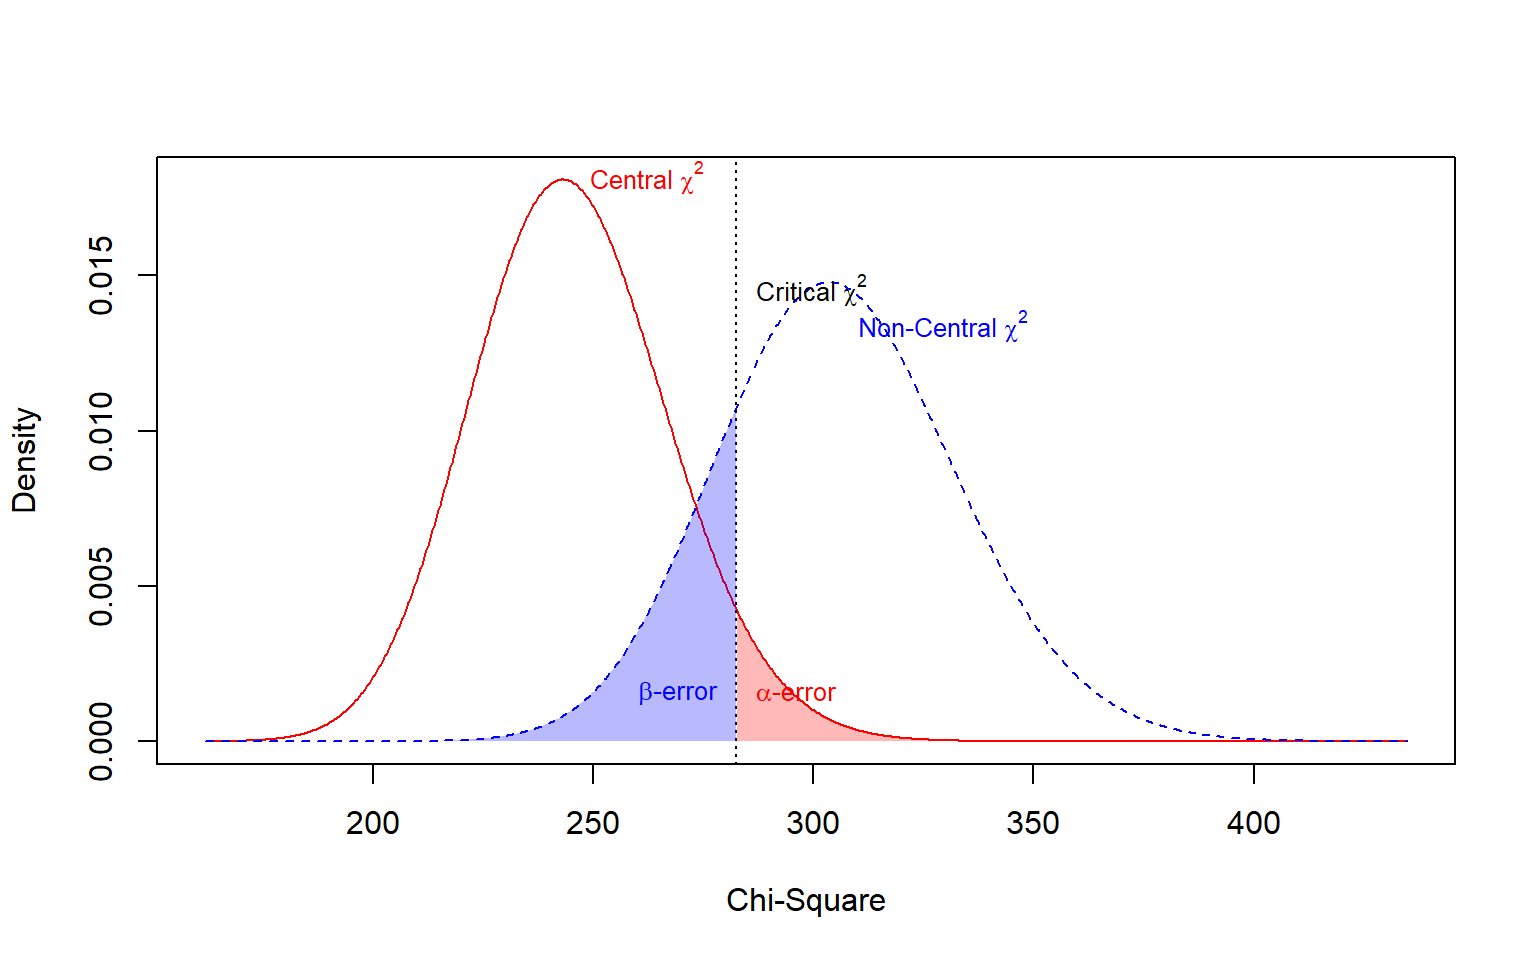
<figcaption>Figure 7: A priori power analysis Model-based approach (h1model vs analyzemodel)</figcaption>
</figure>

### 3.3 Power Curves

Power curves visualize the relationship between sample size and the probability of detecting a prespecified degree of model misspecification, holding $\alpha$ and $df$ constant. They serve as a planning aid by showing at a glance which $N$ values are underpowered and where additional observations yield diminishing returns ([Moshagen & Bader, 2024](#ref-moshagen2024)).

#### 3.3.1 Model-free approach (RMSEA-based)

In the model-free setup, the power function depends entirely on $\text{RMSEA}$, $df$, and $\alpha$ — not on any substantive model parameters. Representing this function graphically answers a direct planning question: for a model with fixed $df$, how large must $N$ be to achieve a sufficiently high probability of detecting misfit of at least the target magnitude ([Jak et al., 2021](#ref-jak2021); [Jobst et al., 2023](#ref-jobst2023))? This visualization is especially useful when the research objective concerns global fit rather than individual parameter restrictions, and it also makes it easy to communicate design justification to reviewers or funding agencies ([Moshagen & Bader, 2024](#ref-moshagen2024); [Wang, 2023](#ref-wang2023)).

``` python
# Plots statistical power against sample size N.
semPower::semPower.powerPlot.byN(
  effect         = 0.05,      # Target misfit in RMSEA units.
  effect.measure = "RMSEA",   # Type of effect measure
  alpha          = ALPHA,     # Type I error rate defined in helpers.R
  df             = df_model,  # Model degrees of freedom calculated in "compute-df" chunk
  power.min      = 0.05,      # Min. Power define the y-axis range
  power.max      = 0.99       # Max. Power define the y-axis range
)
```

<figure id="fig-power-rmsea">
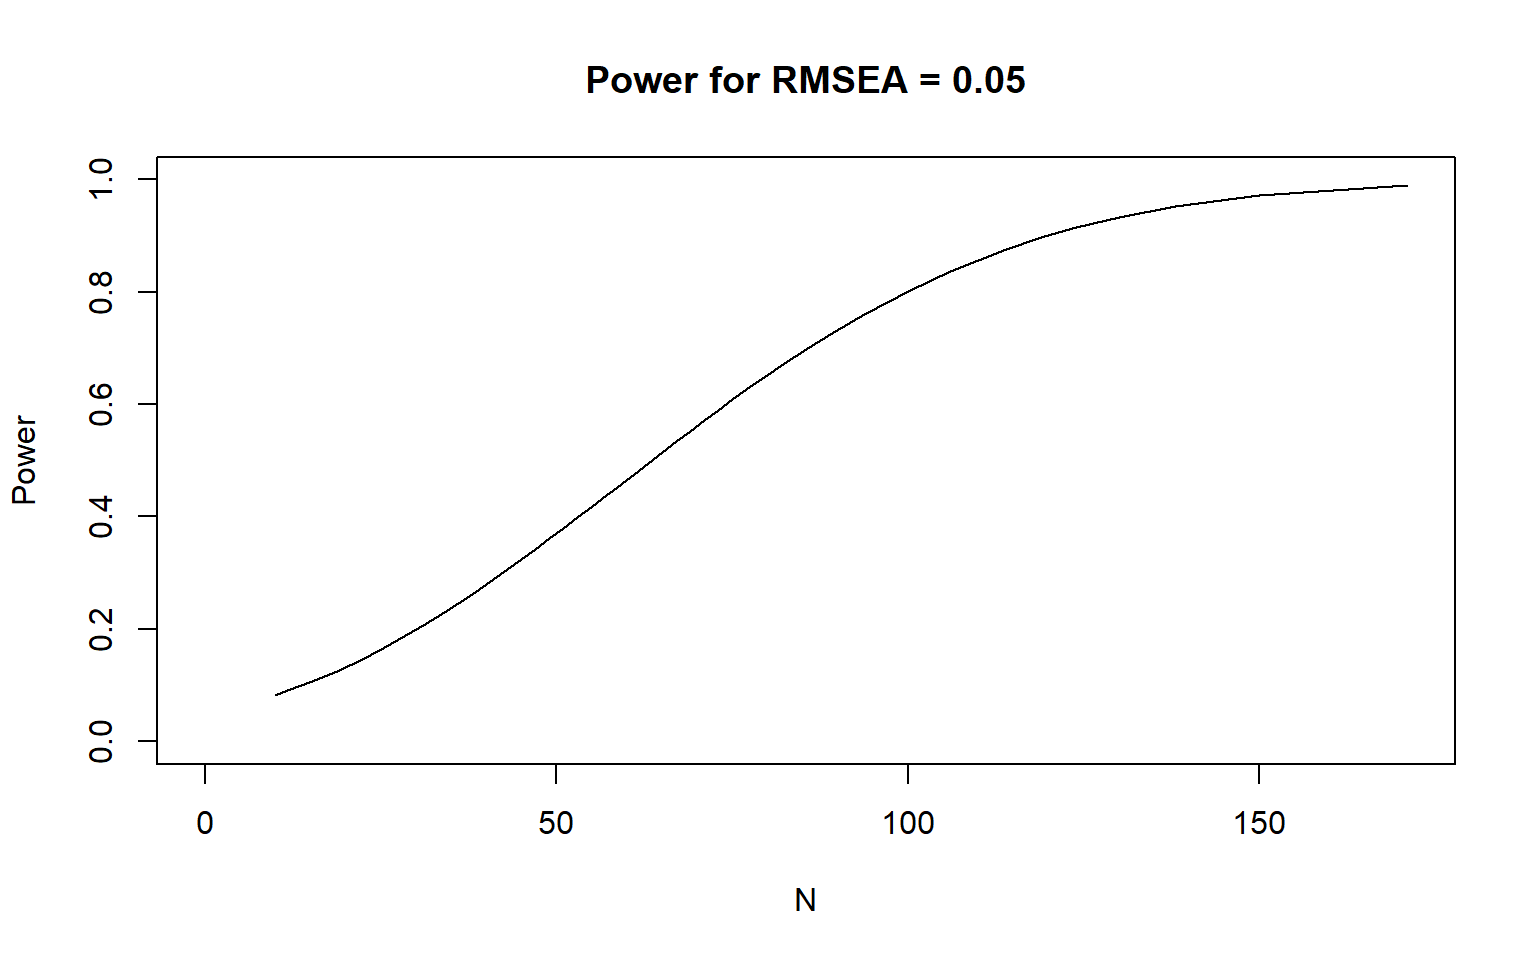
<figcaption>Figure 8: Power as a function of sample size for RMSEA = 0.05</figcaption>
</figure>

Power increases monotonically with $N$. At the lower end of the range, the curve is well below the target threshold, indicating insufficient sensitivity to detect the prespecified misspecification; at higher $N$, it approaches the ceiling. The crossing point between the curve and the target power level identifies the minimum adequate sample size, and the shape of the curve shows how quickly additional observations convert into detection probability in this particular setting.

#### 3.3.2 Model-based approach

When the effect is grounded in an explicitly specified population model, the power curve traces the same monotonic pattern but now reflects the particular covariance structure implied by the substantive hypotheses ([Buchberger et al., 2024](#ref-buchberger2024); [Feng & Hancock, 2023](#ref-feng2023)). `semPower.powerPlot()` evaluates the previously specified model-based effect at each $N$ in the grid, so the curve is a design-oriented summary of how sensitivity changes as sample size grows — without re-estimating any parameters ([Moshagen & Bader, 2024](#ref-moshagen2024)).

``` python
# Plots the power curve based on the previously computed object `ap_popmodel`.
# x-axis: sample size (N).
# y-axis: statistical power.

semPower.powerPlot(ap_popmodel)
```

<figure id="fig-power-popmodel">
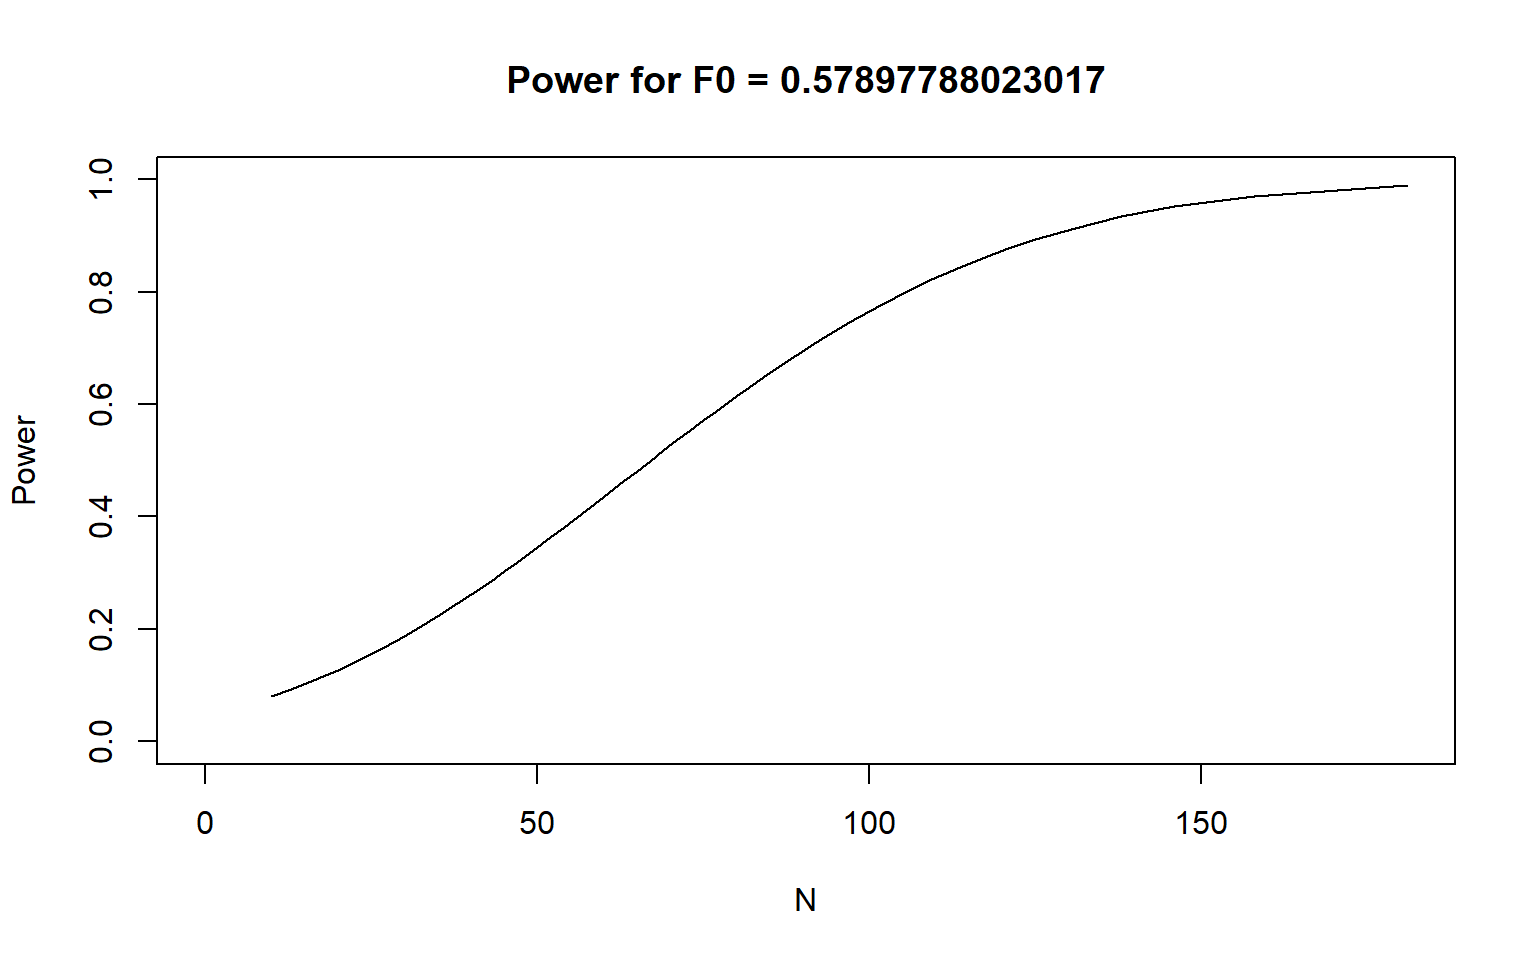
<figcaption>Figure 9: Power as a function of sample size for the population model (popModel)</figcaption>
</figure>

The plot titled Power for $F_0$ = 0.579 shows a clear monotonic increase. At the lower end, power hovers near $0.07$–$0.10$, indicating inadequate sensitivity for small samples. A period of rapid growth occurs between roughly $N = 60$ and $N = 120$, where each additional observation translates into a substantial gain. The conventional $0.80$ threshold is crossed at approximately $N \approx 106$, and power approaches $0.95$ around $N \approx 140$, with further gains becoming marginal above that.

### 3.4 Summary table

<a href="#tbl-analytical-summary" class="quarto-xref">Table 5</a> compares the analytical power solutions. The model-based global fit test requires $N = 106$, closely matching the model-free RMSEA-based target ($N = 100$). This convergence occurs because the misspecification introduced by the three cross-loadings translates into an implied $\text{RMSEA} = 0.0486$, almost identical to the generic $0.05$ threshold.

``` python
# Helper to safely extract a single numeric value from each result object
safe_num <- function(x) if (length(x) == 0 || is.null(x)) NA else as.numeric(x)[1]

# Create a summary table of the analytical power analysis results
analytical_summary <- data.frame(
    Method = c(
        "Model-free a priori (RMSEA = .05)",
        "Model-based global fit (h1model vs. saturated)"
    ),
    `N Required` = c(
        safe_num(ap_rmsea$requiredN),
        safe_num(ap_popmodel$requiredN)
    ),
    `Power` = c(
        round(safe_num(ap_rmsea$impliedPower), 4),
        round(safe_num(ap_popmodel$impliedPower), 4)
    ),
    `Implied RMSEA` = c(
        round(safe_num(ap_rmsea$rmsea), 4),
        round(safe_num(ap_popmodel$rmsea), 4)
    ),
    df = c(
        safe_num(ap_rmsea$df),
        safe_num(ap_popmodel$df)
    ),
    check.names = FALSE
)

# Render the summary table with simple column alignment
knitr::kable(analytical_summary, align = "lcccc")
```

| Method | N Required | Power | Implied RMSEA | df |
|:---------------------------------|-----------|:-------:|:----------:|:----:|
| Model-free a priori (RMSEA = .05) | 100 | 0.8016 | 0.0500 | 245 |
| Model-based global fit (h1model vs. saturated) | 106 | 0.8032 | 0.0486 | 245 |

Table 5: Summary of analytical power analysis results

> **Limitations of the Analytical Approach**
>
> The RMSEA/$\chi^2$-based analytical method assumes continuous, multivariate normal data and Maximum Likelihood estimation. It can yield biased sample size estimates when distributions are non-normal, data are ordinal, or missing data reduce estimation efficiency. Furthermore, because power is framed around global misfit, the analytical approach provides no information about whether $N$ is sufficient to detect specific weak loadings, factor correlations, or structural paths. These limitations motivate the simulation-based extensions developed in subsequent sections.

## 4 Monte Carlo Simulation: Ideal Conditions

Simulation-based power analysis in SEM operates on a different logic from its analytical counterpart. Rather than deriving power from the non-central $\chi^2$ distribution, the approach repeatedly generates data from an assumed population model, fits the analysis model to each replicate, and summarizes rejection rates empirically. This makes the framework far more flexible: it can accommodate complex data conditions, evaluate multiple fit criteria simultaneously, and quantify estimation quality — bias, standard error accuracy, and coverage — alongside power ([Muthén & Muthén, 2002](#ref-muthen2002a); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

The central distinction in the design is between the *data-generating model* and the *analysis model* ([Feng & Hancock, 2023](#ref-feng2023)). The former defines the population from which replicated samples are drawn; the latter defines the structure that is repeatedly fit to each sample. Statistical power in SEM depends not only on $N$, but on the discrepancy between these two models, so this separation is essential ([Feng & Hancock, 2023](#ref-feng2023); [Jobst et al., 2023](#ref-jobst2023)).

In the main analysis, the reference condition uses data generated from `popmodel`, while the alternative condition uses data generated from `h1model` — a structurally equivalent model with three additional cross-loadings. The analysis model (`analyzemodel`) omits those cross-loadings, so power reflects the probability that global fit indices flag this deliberate misspecification. Varying $N$ across a predefined sequence turns the simulation into a sample size planning exercise: as $N$ grows, the sampling distributions under the reference and alternative conditions separate, and the probability of correctly flagging the misspecified condition increases ([Feng & Hancock, 2023](#ref-feng2023); [Jobst et al., 2023](#ref-jobst2023)).

Power based on fit indices is therefore interpreted as the probability that a rejection rule — calibrated from the reference distribution at $\alpha$ — classifies data generated under the alternative as showing worse fit than expected under the well-fitting model. Practically, this shifts the inferential focus from testing a single parameter to evaluating whether global fit criteria are sensitive enough to detect a substantively meaningful form of misspecification across plausible sample sizes ([Liang & Sterba, 2024](#ref-liang2024); [Wang, 2023](#ref-wang2023)).

### 4.1 Main analysis under ideal conditions

The <a href="#fig-fit-curve-ideal" class="quarto-xref">Figure 11</a> and <a href="#fig-power-curve-ideal" class="quarto-xref">Figure 10</a> present the main results for the comparison between `popmodel` and `h1model` under ideal conditions (multivariate normality, no missing data).

``` python
plotPowerFit(
    h1model_ideal,   # Data simulated under H1 (with cross-loadings)
    popmodel_ideal,  # Data simulated under H0 (no cross-loadings)
    alpha = ALPHA,   # Significance level for determining power (see helpers.R)
    usedFit = FITS   # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)
```

<figure id="fig-power-curve-ideal">
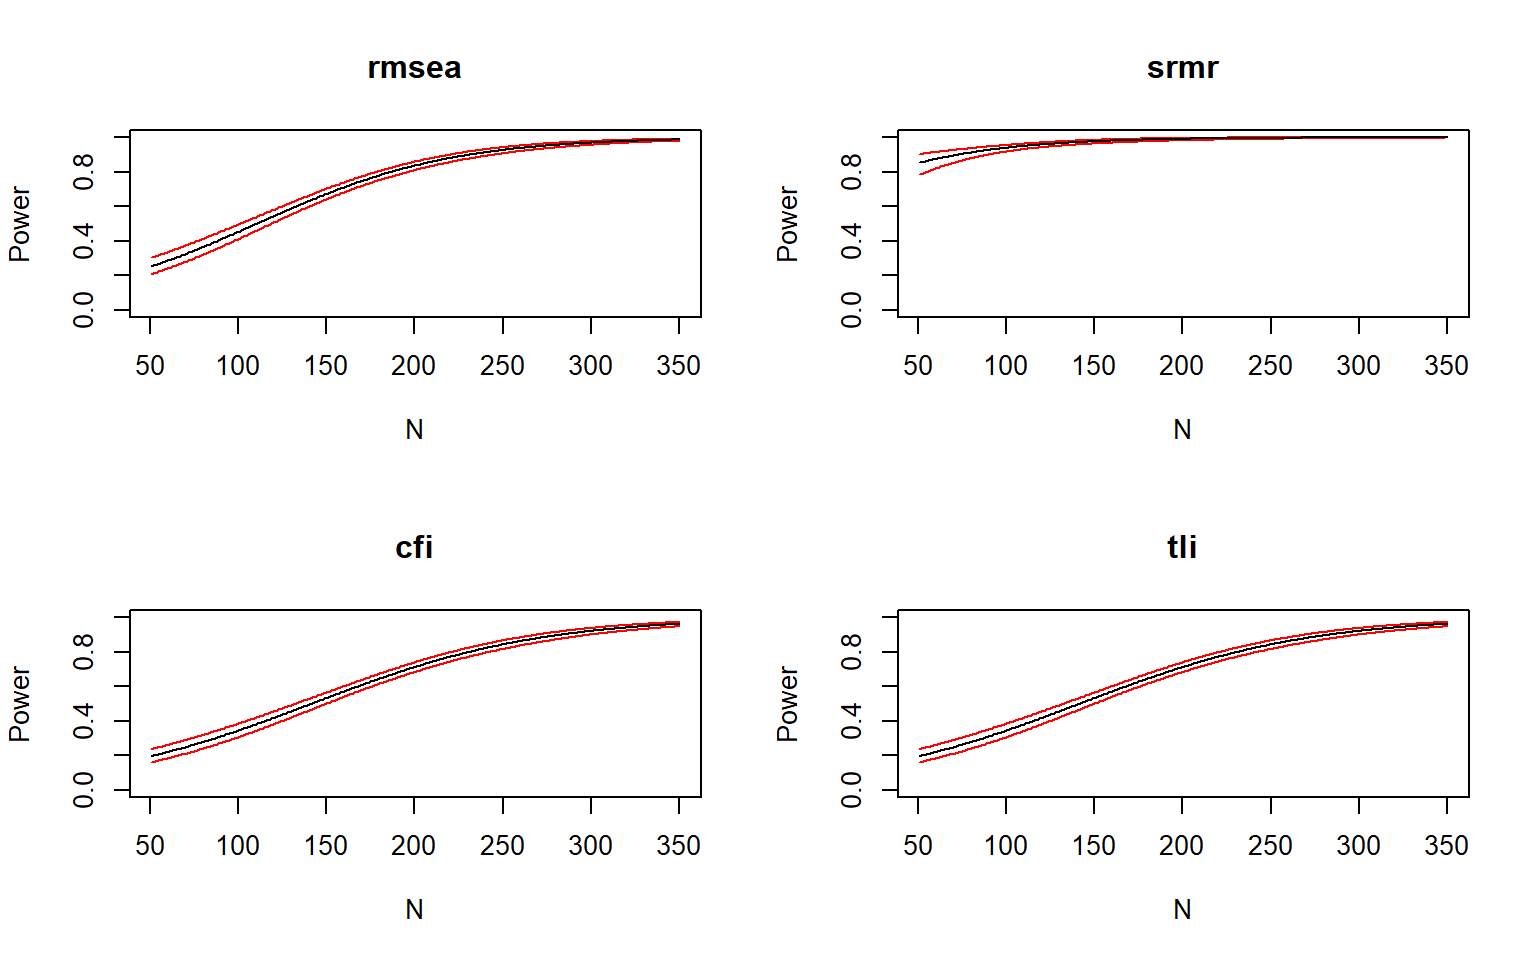
<figcaption>Figure 10: Power curves for fit indices under ideal conditions.</figcaption>
</figure>

Power increases monotonically with $N$ for all four indices. At the lower end of the sample-size sequence, every index falls below the target threshold, indicating insufficient sensitivity. As $N$ grows, the curves diverge: some indices reach the $0.80$ target earlier than others, reflecting different degrees of sensitivity to the imposed cross-loading misspecification. The most conservative planning decision is therefore anchored in the last index to cross the target — the index whose detection requires the largest $N$.

``` python
plotPowerFit(
    h1model_ideal,    # Data simulated under H1 (with cross-loadings)
    popmodel_ideal,   # Data simulated under H0 (no cross-loadings)
    alpha = ALPHA,    # Significance level for determining power (see helpers.R)
    usedFit = FITS,   # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
    logistic = FALSE  # Display raw simulated points and cutoff lines instead of logistic curves
)
```

<figure id="fig-fit-curve-ideal">
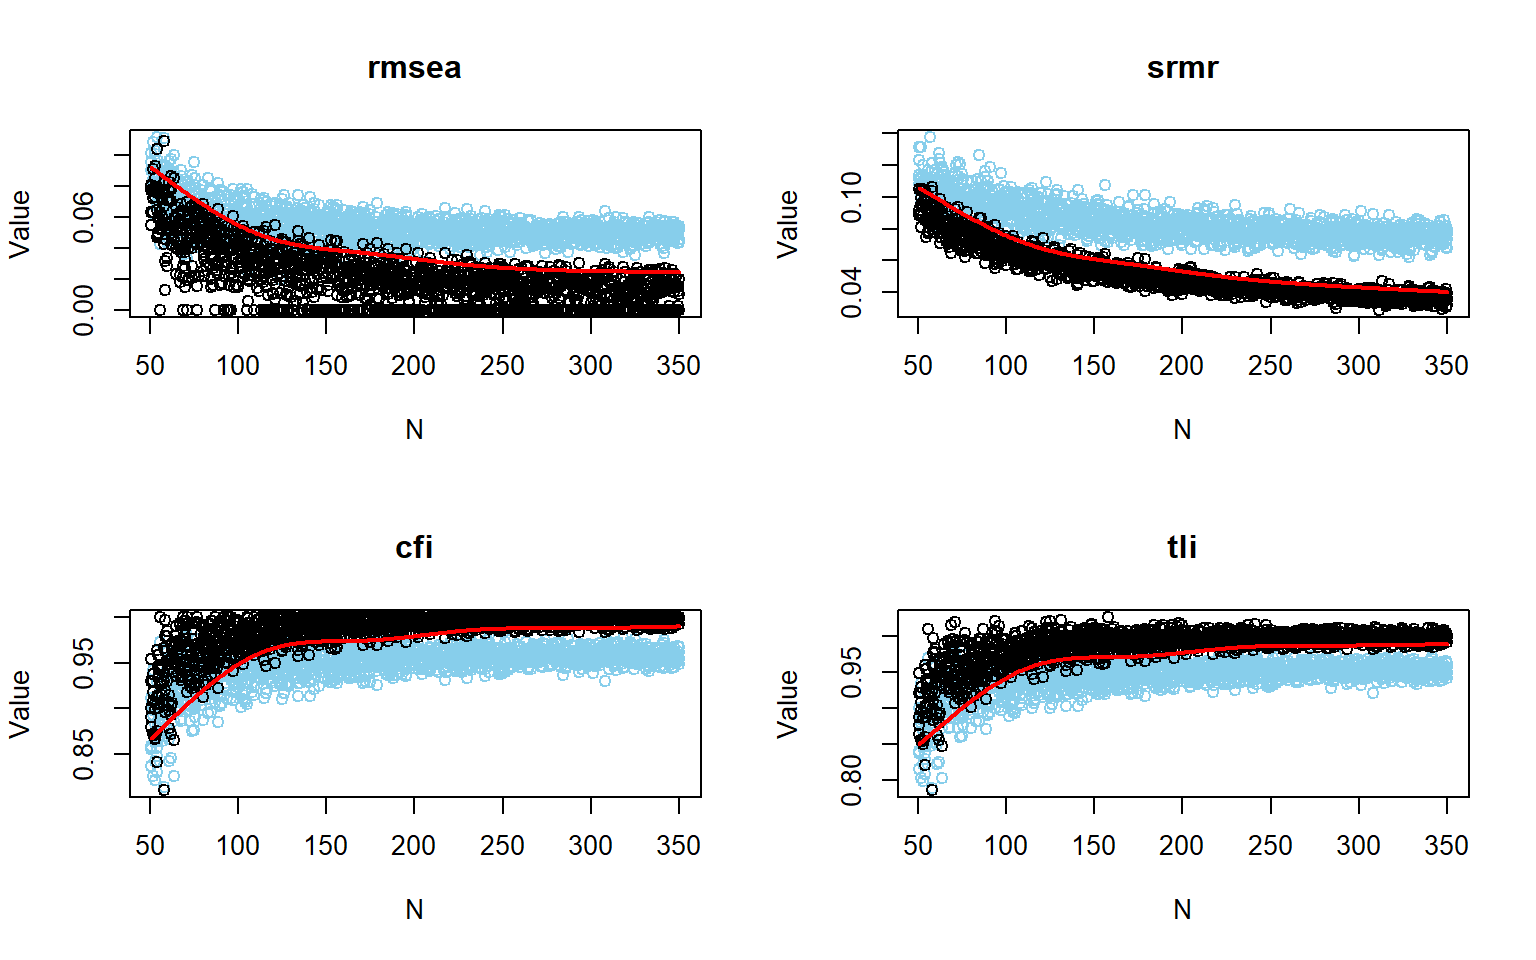
<figcaption>Figure 11: Power curves for fit indices under ideal conditions without logistic smoothing.</figcaption>
</figure>

The <a href="#fig-fit-curve-ideal" class="quarto-xref">Figure 11</a> makes the discrimination mechanism visible. At small $N$, the sampling distributions of each fit index under the reference and alternative conditions overlap substantially, so the indices cannot reliably distinguish the two scenarios. As $N$ increases, the alternative-condition distribution shifts toward worse fit while the reference distribution remains stable, widening the gap between them. This growing separation is the empirical basis for the power gains shown in the <a href="#fig-power-curve-ideal" class="quarto-xref">Figure 10</a>, and it provides an intuitive picture of how fit indices work as decision variables rather than mere descriptive summaries ([McNeish & Wolf, 2021](#ref-mcneish2021); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

``` python
# Estimate power for rejecting the misspecified model (h1model_ideal)
# using fit-index cutoffs implied by the null model (popmodel_ideal) at alpha = ALPHA and N = 231.
power_ideal <- getPowerFit(
    h1model_ideal,                # Data simulated under H1 (with cross-loadings)
    nullObject = popmodel_ideal,  # Data simulated under H0 (no cross-loadings)
    alpha = ALPHA,                # Significance level for determining power (see helpers.R)
    nVal = 231,                   # Sample size for analysis
    usedFit = FITS                # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Derive empirical cutoff values for the selected fit indices
# from the null-model sampling distribution under the same conditions.
cutoff_ideal <- getCutoff(
    popmodel_ideal,               # Data simulated under H0 (no cross-loadings)
    alpha = ALPHA,                # Significance level for determining power (see helpers.R)
    nVal = 231,                   # Sample size for analysis
    usedFit = FITS                # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Combine power and cutoff values into a compact summary table.
power_cutoff_ideal <- rbind(
    "Power" = as.numeric(power_ideal),
    "Cutoff" = as.numeric(cutoff_ideal[1, ])
)

# Standardize column names for presentation.
colnames(power_cutoff_ideal) <- toupper(names(power_ideal)) 

# Print the table.
knitr::kable(power_cutoff_ideal, digits = 3, align = "c") 
```

|        | RMSEA | SRMR  |  CFI  |  TLI  |
|--------|:-----:|:-----:|:-----:|:-----:|
| Power  | 0.900 | 0.995 | 0.801 | 0.801 |
| Cutoff | 0.039 | 0.058 | 0.965 | 0.961 |

Table 6: Power and fit index cutoff values under ideal conditions at N = 231.

At $N = 231$, power was 0.9 for RMSEA, 0.995 for SRMR, and 0.801 for both CFI and TLI. The ordering SRMR \> RMSEA \> CFI $\approx$ TLI is consistent across the power curves. The empirical cutoffs were 0.039 for RMSEA, 0.058 for SRMR, 0.965 for CFI, and 0.961 for TLI, defining the data-driven rejection boundaries at this $N$. Taken together, the results confirm that $N = 231$ is sufficient for all four indices to achieve at least $0.80$ power in the ideal scenario, with SRMR and RMSEA providing a comfortable margin and CFI/TLI operating near the minimum threshold ([Jobst et al., 2023](#ref-jobst2023); [McNeish & Wolf, 2021](#ref-mcneish2021)).

### 4.2 Traditional cutoff values for fit indices

When traditional thresholds are applied — $\text{RMSEA} \le .06$, $\text{CFI} \ge .95$, $\text{TLI} \ge .95$, $\text{SRMR} \le .06$ — power is defined as the proportion of replications in which the misspecified model crosses those fixed boundaries in the direction of worse fit. This mirrors common applied practice, but a key limitation is that these thresholds were derived under specific simulation conditions and may not be universally valid across different model structures and sample sizes ([Kyriazos, 2018](#ref-kyriazos2018); [McNeish & Wolf, 2021](#ref-mcneish2021)).

``` python
# Plot fit-index results from the misspecified model across sample sizes.
# The cutoff object applies traditional rule-of-thumb thresholds
# (e.g., RMSEA, SRMR, CFI, and TLI cutoffs) for rejection decisions.
# logistic = FALSE requests the scatterplot-style display of simulated values
# and the cutoff line, instead of a logistic-smoothed power curve

plotPowerFit(
  h1model_ideal,          # Data simulated under H1 (with cross-loadings)
  popmodel_ideal,         # Data simulated under H0 (no cross-loadings)
  cutoff = RULE_OF_THUMB, # Rule-of-thumb cutoff values for fit indices (see helpers.R)
  alpha = ALPHA,          # Significance level for determining power (see helpers.R)
  usedFit = FITS,         # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
  logistic = FALSE        # Display raw simulated points and cutoff lines instead of logistic curves
)
```

<figure id="fig-fit-curve-traditional">
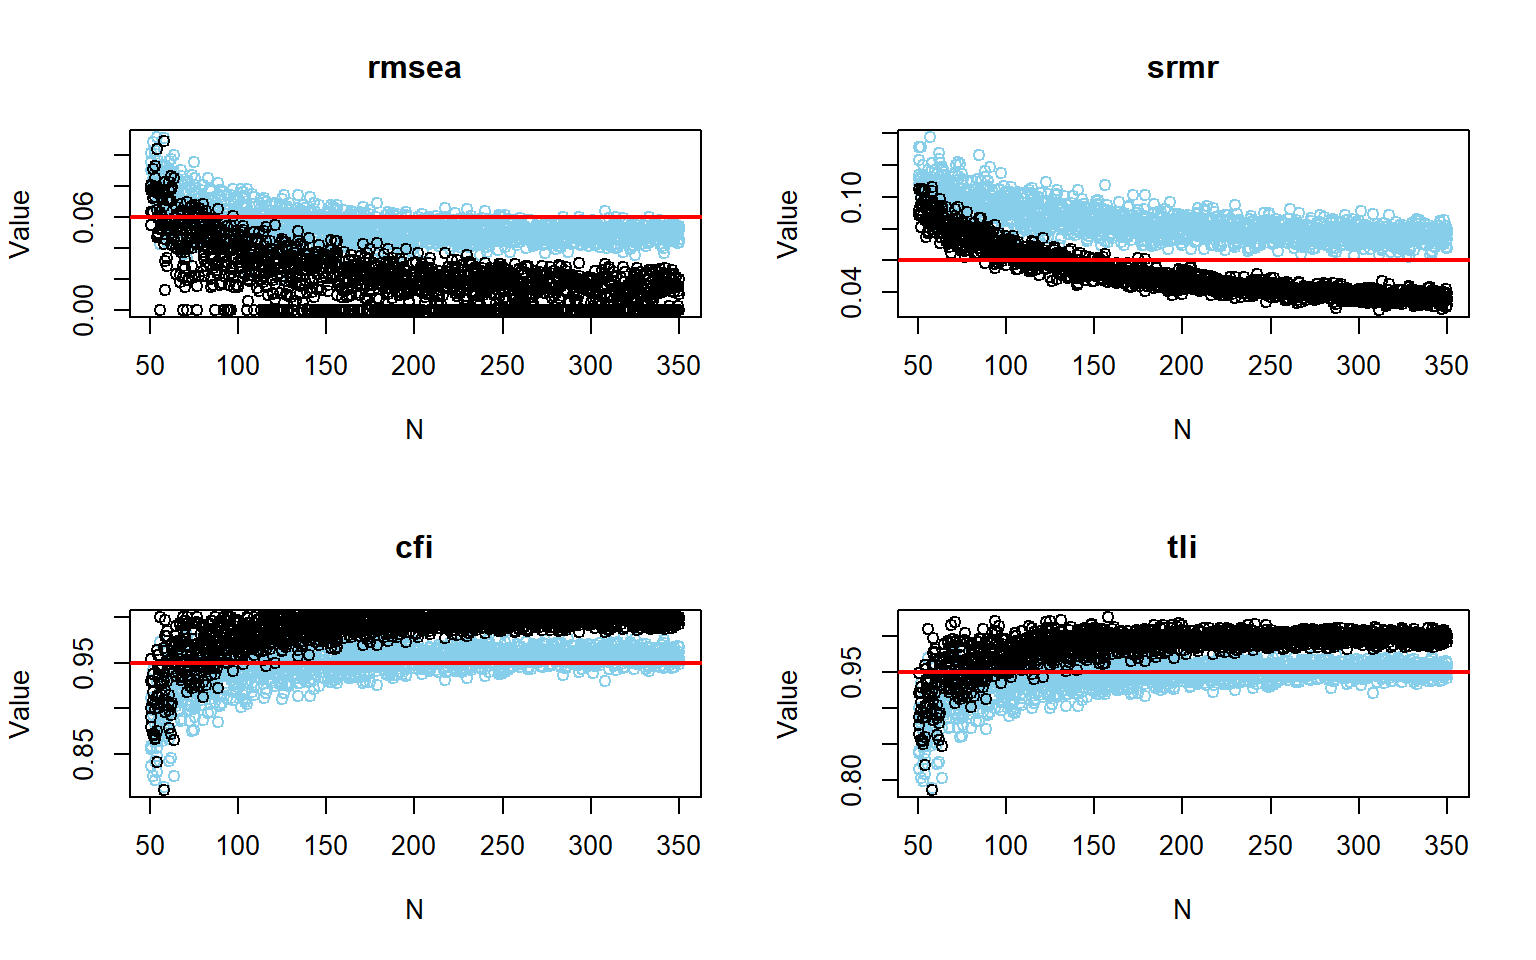
<figcaption>Figure 12: Power curves using traditional fit index cutoffs under ideal conditions.</figcaption>
</figure>

The contrast with the empirical-cutoff results is instructive. SRMR is the only index that achieves clear visual discrimination under the traditional threshold, and only at $N \approx 200$ or larger. RMSEA shows some separation but would require a cutoff near $0.04$ rather than $0.06$ to make a meaningful distinction in this figure. CFI and TLI show essentially no discrimination at the $0.95$ threshold because both the reference and alternative point clouds cluster in the same region throughout the sample-size range (<a href="#fig-fit-curve-traditional" class="quarto-xref">Figure 12</a>). The <a href="#tbl-power-cutoff-traditional-ideal" class="quarto-xref">Table 7</a> summarizes the power for each fit index under the traditional cutoff values.

``` python
# Estimate power for rejecting the misspecified model (h1model_ideal)
# using traditional rule-of-thumb cutoffs (RULE_OF_THUMB) at alpha = ALPHA and N = 231.
power_trad <- getPowerFit(
    h1model_ideal,    # Data simulated under H1 (with cross-loadings)
    RULE_OF_THUMB,    # Rule-of-thumb cutoff values for fit indices (see helpers.R)
    alpha = ALPHA,    # Significance level for determining power (see helpers.R)
    nVal = 231,       # Sample size for analysis
    usedFit = FITS    # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Create horizontal table: Fit Index as column names, Power as single row
power_df <- data.frame(
    "CFI" = round(as.numeric(power_trad["cfi"]), 3),
    "TLI" = round(as.numeric(power_trad["tli"]), 3),
    "RMSEA" = round(as.numeric(power_trad["rmsea"]), 3),
    "SRMR" = power_trad["srmr"],
    row.names = "Power"
)

# Print the table.
knitr::kable(power_df, digits = 3, align = "c", col.names = toupper(names(power_df)))
```

|       |  CFI  |  TLI  | RMSEA |  SRMR   |
|-------|:-----:|:-----:|:-----:|:-------:|
| Power | 0.381 | 0.579 | 0.153 | \> 0.98 |

Table 7: Power for traditional fit index cutoffs under ideal conditions at N = 231.

### 4.3 Targeting specific parameters

The previous analyses focused on global fit. However, power is always tied to a specific hypothesis, and different parameters within the same model can require markedly different $N$ to reach the same target ([Moshagen & Bader, 2024](#ref-moshagen2024); [Wang, 2023](#ref-wang2023)). This section evaluates power at the parameter level to identify which parts of the model are hardest to recover and should therefore anchor the sample size decision.

In `simsem`, parameter-level summaries include relative bias, standard-error bias, CI coverage, and detection power. These four indicators are not redundant: a parameter may show high power while still being poorly estimated, and estimation quality should always be verified alongside detection rates ([Pornprasertmanit et al., 2021](#ref-simsem2021); [Wang & Rhemtulla, 2021](#ref-wang2021)).

``` python
# Compute detailed parameter-recovery results for the fitted model.
param_ideal <- summaryParam(
  h1model_ideal,   # Data simulated under H1 (with cross-loadings)
  alpha = ALPHA,   # Significance level for determining power (see helpers.R)
  digits = 3,      # Number of decimal places for output
  detail = TRUE    # Display detailed parameter-recovery results
)

# Keep only the diagnostics used in the discussion.
param_subset <- param_ideal[, c("Rel Bias", "Rel SE Bias", "Coverage", "Power (Not equal 0)")]

# Move parameter labels to an explicit first column.
param_subset <- cbind(
  Parameter = rownames(param_subset),
  param_subset,
  row.names = NULL
)

# Escape ~~ for Pandoc (prevents strikethrough in HTML); matches tbl-pop-summary
param_subset$Parameter <- gsub("~~", "\\~\\~", param_subset$Parameter, fixed = TRUE)

# Print the table.
knitr::kable(
  param_subset,
  digits = 3,
  align = c("l", "c", "c", "c", "c"),
  booktabs = TRUE,
  escape = FALSE,
  row.names = FALSE
)
```

| Parameter              | Rel Bias | Rel SE Bias | Coverage | Power (Not equal 0) |
|:----------------------|:---------|-----------|:--------:|------------------|
| psycho=~Q5             | -0.003   | -0.043      |  0.947   | 1.000               |
| psycho=~Q6             | -0.005   | -0.084      |  0.937   | 1.000               |
| psycho=~Q7             | -0.004   | -0.066      |  0.940   | 1.000               |
| psycho=~Q11            | -0.005   | -0.050      |  0.945   | 1.000               |
| psycho=~Q19            | -0.003   | 0.000       |  0.953   | 1.000               |
| psycho=~Q26            | -0.006   | -0.079      |  0.938   | 1.000               |
| physical=~Q3           | -0.011   | -0.063      |  0.947   | 1.000               |
| physical=~Q4           | -0.006   | -0.066      |  0.945   | 1.000               |
| physical=~Q10          | -0.010   | -0.062      |  0.947   | 1.000               |
| physical=~Q15          | 0.068    | -0.106      |  0.871   | 1.000               |
| physical=~Q16          | -0.011   | -0.061      |  0.941   | 1.000               |
| physical=~Q17          | -0.010   | -0.090      |  0.931   | 1.000               |
| physical=~Q18          | -0.011   | -0.077      |  0.938   | 1.000               |
| social=~Q20            | -0.004   | -0.050      |  0.941   | 1.000               |
| social=~Q21            | -0.003   | -0.025      |  0.952   | 1.000               |
| social=~Q22            | 0.002    | -0.048      |  0.943   | 1.000               |
| environment=~Q8        | 0.360    | -0.090      |  0.520   | 0.997               |
| environment=~Q9        | 0.105    | -0.051      |  0.879   | 0.999               |
| environment=~Q12       | -0.012   | -0.065      |  0.939   | 1.000               |
| environment=~Q13       | -0.010   | -0.080      |  0.942   | 1.000               |
| environment=~Q14       | -0.009   | -0.045      |  0.940   | 1.000               |
| environment=~Q23       | -0.010   | -0.075      |  0.939   | 1.000               |
| environment=~Q24       | -0.006   | -0.047      |  0.947   | 1.000               |
| environment=~Q25       | -0.011   | -0.059      |  0.940   | 1.000               |
| psycho\~~physical      | 0.039    | -0.069      |  0.941   | 0.751               |
| psycho\~~social        | -0.002   | -0.069      |  0.935   | 0.727               |
| psycho\~~environment   | 0.286    | -0.122      |  0.831   | 0.857               |
| physical\~~social      | 0.046    | -0.047      |  0.944   | 0.760               |
| physical\~~environment | 0.239    | -0.091      |  0.875   | 0.839               |
| social\~~environment   | 0.038    | -0.070      |  0.931   | 0.736               |
| Q3\~~Q4                | 0.007    | -0.050      |  0.944   | 0.775               |
| Q5\~~Q5                | -0.012   | -0.043      |  0.944   | 0.999               |
| Q6\~~Q6                | -0.017   | -0.039      |  0.934   | 1.000               |
| Q7\~~Q7                | -0.020   | -0.071      |  0.929   | 0.993               |
| Q11\~~Q11              | -0.014   | -0.073      |  0.926   | 1.000               |
| Q19\~~Q19              | -0.014   | -0.050      |  0.933   | 1.000               |
| Q26\~~Q26              | -0.018   | -0.038      |  0.933   | 1.000               |
| Q3\~~Q3                | -0.012   | -0.059      |  0.935   | 1.000               |
| Q4\~~Q4                | -0.015   | -0.040      |  0.944   | 1.000               |
| Q10\~~Q10              | -0.008   | -0.044      |  0.934   | 1.000               |
| Q15\~~Q15              | 0.105    | -0.068      |  0.896   | 1.000               |
| Q16\~~Q16              | -0.011   | -0.055      |  0.934   | 1.000               |
| Q17\~~Q17              | -0.008   | -0.084      |  0.934   | 0.999               |
| Q18\~~Q18              | -0.008   | -0.010      |  0.949   | 1.000               |
| Q20\~~Q20              | -0.004   | -0.091      |  0.943   | 0.848               |
| Q21\~~Q21              | -0.015   | -0.042      |  0.946   | 0.991               |
| Q22\~~Q22              | -0.018   | -0.050      |  0.933   | 1.000               |
| Q8\~~Q8                | 0.536    | -0.058      |  0.136   | 1.000               |
| Q9\~~Q9                | 0.028    | -0.059      |  0.944   | 1.000               |
| Q12\~~Q12              | -0.001   | -0.036      |  0.943   | 1.000               |
| Q13\~~Q13              | 0.004    | -0.042      |  0.936   | 1.000               |
| Q14\~~Q14              | -0.002   | -0.085      |  0.937   | 1.000               |
| Q23\~~Q23              | -0.001   | -0.029      |  0.945   | 1.000               |
| Q24\~~Q24              | -0.013   | -0.055      |  0.937   | 1.000               |
| Q25\~~Q25              | -0.007   | -0.058      |  0.942   | 1.000               |

Table 8: Summary of parameter estimates under ideal conditions.

Primary factor loadings for `psycho`, `physical`, and `social` recover very well: high power, minimal bias, modest SE distortion, and coverage close to nominal. Two exceptions stand out. The loading of $Q8$ on `environment` and its residual variance are easily detected but not well recovered — the model would flag this parameter as non-zero while still estimating it with noticeable distortion. Item $Q15$ shows a secondary warning on the same dimensions. Among the latent parameters, interfactor covariances — particularly those involving `social` and `environment` — are harder to recover than loadings, with lower power and weaker coverage. The residual covariance $Q3 \sim\sim Q4$ stands out as the most demanding residual parameter, behaving more like a latent covariance than a measurement parameter in terms of inferential difficulty.

The required $N$ for each parameter follows directly from these patterns ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)), as shown in <a href="#tbl-power-n-ideal" class="quarto-xref">Table 9</a>.

``` python
# Obtain parameter-specific power estimates across sample sizes.
pow_h1 <- getPower(h1model_ideal, alpha = ALPHA)

# Find the minimum N in the simulated grid that reaches the target power of 0.80.
n_h1 <- findPower(pow_h1, "N", 0.80)

# Convert to a data frame for reporting.
n_df <- data.frame(
  Parameter = names(n_h1),
  N = suppressWarnings(as.integer(n_h1)),
  stringsAsFactors = FALSE
)

# Remove parameters for which no finite N was returned.
n_df <- subset(n_df, is.finite(N))

# Escape ~~ for Pandoc (prevents strikethrough in HTML); matches tbl-pop-summary
n_df$Parameter <- gsub("~~", "\\~\\~", n_df$Parameter, fixed = TRUE)

# Print the table without row numbers.
knitr::kable(
  n_df,
  col.names = c("Parameter", "N"),
  align = c("l", "c"),
  booktabs = TRUE,
  escape = FALSE,
  row.names = FALSE
)
```

| Parameter              |  N  |
|:-----------------------|:---:|
| environment=~Q8        | 51  |
| environment=~Q9        | 51  |
| psycho\~~physical      | 200 |
| psycho\~~social        | 212 |
| psycho\~~environment   | 138 |
| physical\~~social      | 198 |
| physical\~~environment | 148 |
| social\~~environment   | 208 |
| Q3\~~Q4                | 181 |
| Q5\~~Q5                | 51  |
| Q7\~~Q7                | 51  |
| Q17\~~Q17              | 51  |
| Q20\~~Q20              | 143 |
| Q21\~~Q21              | 51  |

Table 9: Sample size needed for 80% power under ideal conditions.

Many primary loadings and residual variances reach the target power at the low end of the simulated range. Latent covariances and the residual covariance $Q3 \sim\sim Q4$ require substantially larger samples. In practice, the sample size decision should be driven by the hardest-to-detect parameters, not by the easiest ones — a principle that pushes the practical reference toward $N \approx 200$ rather than $N \approx 50$ ([Pornprasertmanit et al., 2021](#ref-simsem2021); [Wang & Rhemtulla, 2021](#ref-wang2021)). Specifically, the `psycho~~social` covariance requires $N$ = 212, which sets the effective ceiling for parameter-level planning in this model.

### 4.4 Recovering population parameters

#### 4.4.1 Parameter-level power under the naive model

Examining parameter recovery under the naive model serves as a conservative benchmark for the measurement structure: because this population assumes the weakest factor loadings ($\lambda \approx 0.40$), indicator communalities are low, which increases estimation uncertainty for the measurement parameters ([<span class="nocase">Mosqueira Taipe et al.</span>, 2026](#ref-mosqueirataipe2026)). Concurrently, its interfactor correlations are moderate ($\phi = 0.30$). For detecting latent covariances, a larger effect size ($\phi = 0.30$) requires a substantially smaller sample size than a near-zero correlation, allowing all six factor correlations to reach $80\%$ power within $N \le 90$ ([Pornprasertmanit et al., 2021](#ref-simsem2021); [Wang & Rhemtulla, 2021](#ref-wang2021)).

``` python
# Compute detailed parameter-recovery results for the fitted model.
param_naive <- summaryParam(
  naivemodel_ideal,  # Simulation results from the naive population model (low loadings)
  alpha = ALPHA,     # Significance level for determining power (see helpers.R)
  digits = 3,        # Number of digits to round the results to
  detail = TRUE      # Return detailed parameter-level results
)

# Keep only the diagnostics used in the discussion.
param_subset <- as.data.frame(
  param_naive[, c("Rel Bias", "Rel SE Bias", "Coverage", "Power (Not equal 0)")]
)

# Compute parameter-level power across the simulated values of N.
pow_naive <- getPower(naivemodel_ideal, alpha = ALPHA)

# Extract the minimum N that reaches the target power of .80 for each parameter.
n_naive <- findPower(pow_naive, "N", 0.80)

# Add required N to the subset.
param_subset$N <- suppressWarnings(as.integer(n_naive[rownames(param_subset)]))

# Filter to keep only finite N values greater than 60.
filtered_subset <- subset(param_subset, is.finite(N) & N > 60)

# Move parameter labels to an explicit first column.
filtered_subset <- cbind(
  Parameter = rownames(filtered_subset),
  filtered_subset,
  row.names = NULL
)

# Escape ~~ for Pandoc (prevents strikethrough in HTML); matches tbl-pop-summary
filtered_subset$Parameter <- gsub("~~", "\\~\\~", filtered_subset$Parameter, fixed = TRUE)

# Print the combined table.
knitr::kable(
  filtered_subset,
  digits = 3,
  align = c("l", "c", "c", "c", "c", "c"),
  booktabs = TRUE,
  escape = FALSE,
  col.names = c(
    "Parameter",
    "Rel Bias",
    "Rel SE Bias",
    "Coverage",
    "Power (Not equal 0)",
    "Required N"
  )
)
```

| Parameter | Rel Bias | Rel SE Bias | Coverage | Power (Not equal 0) | Required N |
|:--------------------|--------|:--------:|:--------:|:------------:|----------|
| psycho\~~physical | 0.140 | -0.944 | 0.913 | 0.793 | 180 |
| psycho\~~social | -0.009 | -0.137 | 0.922 | 0.780 | 186 |
| psycho\~~environment | -0.003 | -0.089 | 0.931 | 0.817 | 164 |
| physical\~~social | 0.331 | -0.971 | 0.924 | 0.775 | 192 |
| physical\~~environment | 0.141 | -0.932 | 0.929 | 0.793 | 178 |
| social\~~environment | -0.014 | -0.123 | 0.928 | 0.780 | 184 |
| Q3\~~Q4 | -0.013 | -0.130 | 0.932 | 0.845 | 143 |

Table 10: Parameter estimates and required sample size for 80% power under naive conditions.

Most factor loadings reach the $0.80$ target with $N < 60$, confirming that the loading structure is not the binding constraint. The binding constraint is the set of latent covariances. Their required sample sizes are: $\text{psycho} \sim\sim \text{physical}$ = 180, $\text{psycho} \sim\sim \text{social}$ = 186, $\text{psycho} \sim\sim \text{environment}$ = 164, $\text{physical} \sim\sim \text{social}$ = 192, $\text{physical} \sim\sim \text{environment}$ = 178, and $\text{social} \sim\sim \text{environment}$ = 184. The residual covariance $Q3 \sim\sim Q4$ requires $N$ = 143, placing it between the loadings and the latent covariances in difficulty. The largest required $N$ is $\text{physical} \sim\sim \text{social}$ = 192, which therefore governs the minimum sample size for the naive scenario.

#### 4.4.2 Parameter-level power under the optimistic model

Under the optimistic model, stronger loadings ($\lambda \approx 0.80$) and lower interfactor correlations ($\phi = 0.08$) yield two sharply contrasting patterns ([<span class="nocase">Mosqueira Taipe et al.</span>, 2026](#ref-mosqueirataipe2026)). Because the measurement structure is exceptionally strong, all primary factor loadings and residual variances reach $0.80$ power at the lowest simulated sample size ($N \le 51$) with negligible bias. Conversely, because the true interfactor correlations are very weak ($\phi = 0.08$), detecting them as statistically different from zero requires substantially larger samples: analytical power calculations indicate that reaching $80\%$ power for $\phi = 0.08$ requires $N > 1,200$. Within the simulated sample-size range ($N \in [51, 350]$), power for these correlations never crosses $0.80$, leading `findPower` to return `NA`.

``` python
# Compute detailed parameter-recovery results for the fitted model.
param_opt <- summaryParam(
  optmodel_ideal,   # Simulation results from the optimal population model (stronger factor loadings)
  alpha = ALPHA,    # Significance level for determining power (see helpers.R)
  digits = 3,       # Number of digits to round the results to
  detail = TRUE     # Return detailed parameter-level results
)

# Keep only the diagnostics used in the discussion.
param_subset <- as.data.frame(
  param_opt[, c("Rel Bias", "Rel SE Bias", "Coverage", "Power (Not equal 0)")]
)

# Compute parameter-level power across the simulated values of N.
pow_opt <- getPower(optmodel_ideal, alpha = ALPHA)

# Extract the minimum N that reaches the target power of .80 for each parameter.
n_opt <- findPower(pow_opt, "N", 0.80)

# Add required N to the subset.
param_subset$N <- suppressWarnings(as.integer(n_opt[rownames(param_subset)]))

# Filter to keep only finite N values greater than 60.
filtered_subset <- subset(param_subset, is.finite(N) & N > 60)

# Move parameter labels to an explicit first column.
filtered_subset <- cbind(
  Parameter = rownames(filtered_subset),
  filtered_subset,
  row.names = NULL
)

# Escape ~~ for Pandoc (prevents strikethrough in HTML); matches tbl-pop-summary
filtered_subset$Parameter <- gsub("~~", "\\~\\~", filtered_subset$Parameter, fixed = TRUE)

# Print the combined table.
knitr::kable(
  filtered_subset,
  digits = 3,
  align = c("l", "c", "c", "c", "c", "c"),
  booktabs = TRUE,
  escape = FALSE,
  col.names = c(
    "Parameter",
    "Rel Bias",
    "Rel SE Bias",
    "Coverage",
    "Power (Not equal 0)",
    "Required N"
  )
)
```

| Parameter | Rel Bias | Rel SE Bias | Coverage | Power (Not equal 0) | Required N |
|:----------|:---------|:------------|:--------:|---------------------|:-----------|
| Q3\~~Q4   | -0.008   | -0.082      |  0.934   | 0.85                | 139        |

Table 11: Parameter estimates and required sample size for 80% power under optimal conditions.

Among parameters with finite required $N$ above 60, only the residual covariance $Q3 \sim\sim Q4$ appears in <a href="#tbl-power-n-opt" class="quarto-xref">Table 11</a>, requiring $N$ = 139. Rather than implying that the entire model is powered at $N = 51$, this analysis reveals that weak latent correlations represent an acute bottleneck for parameter-level hypothesis testing, even when measurement quality is optimal ([Buchberger et al., 2024](#ref-buchberger2024); [Pornprasertmanit et al., 2021](#ref-simsem2021)). The contrast between the naive and optimistic results demonstrates how sensitive $N$ recommendations are to the assumed population: the same model structure implies very different requirements depending on which parameter set is used, reinforcing the importance of sensitivity analyses across population variants ([Buchberger et al., 2024](#ref-buchberger2024); [Irmer et al., 2024](#ref-irmer2024)).

## 5 Monte Carlo Simulation: Realistic Scenarios

The ideal-condition analyses establish a theoretical baseline, but actual data collection rarely conforms to multivariate normality with complete observations. When non-normality or missing data are anticipated, analytical power estimates may be optimistic, and the required $N$ should be reassessed under more realistic assumptions ([Feng & Hancock, 2023](#ref-feng2023); [Wang, 2023](#ref-wang2023)). Monte Carlo simulation is especially valuable here because it can encode precisely the data conditions expected in practice — including the missing-data mechanism, the distributional shape, and the estimator — and propagate them through to the power estimate ([Irmer et al., 2024](#ref-irmer2024); [Schoemann et al., 2014](#ref-schoemann2014)).

The goal of this section is not to replace the ideal-condition results but to probe how sensitive they are to two common violations: missing data and non-normality. Both analyses follow the same design logic as before — reference data from `popmodel`, alternative data from `h1model`, analysis model `analyzemodel` — so the results remain directly comparable ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)).

### 5.1 Missing Data (MCAR)

Missing data reduce the amount of usable information per participant and therefore generally lower estimation efficiency and statistical power, even when data are missing completely at random (MCAR) and the analysis model handles missingness correctly via full information maximum likelihood ([Jak et al., 2021](#ref-jak2021); [Wolf et al., 2013](#ref-wolf2013)). The relevant design question is not only how many cases are planned but how much information survives the anticipated missing-data process ([Feng & Hancock, 2023](#ref-feng2023)).

In this simulation, 10% of observations are set missing at random prior to each analysis. All other aspects of the design are unchanged from the ideal-condition analysis.

``` python
plotPowerFit(
    h1model_miss,     # Data simulated under H1 (with cross-loadings)
    popmodel_miss,    # Data simulated under H0 (reference model)
    alpha = ALPHA,    # Significance level for determining power (see helpers.R)
    usedFit = FITS    # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)
```

<figure id="fig-power-curve-missing">
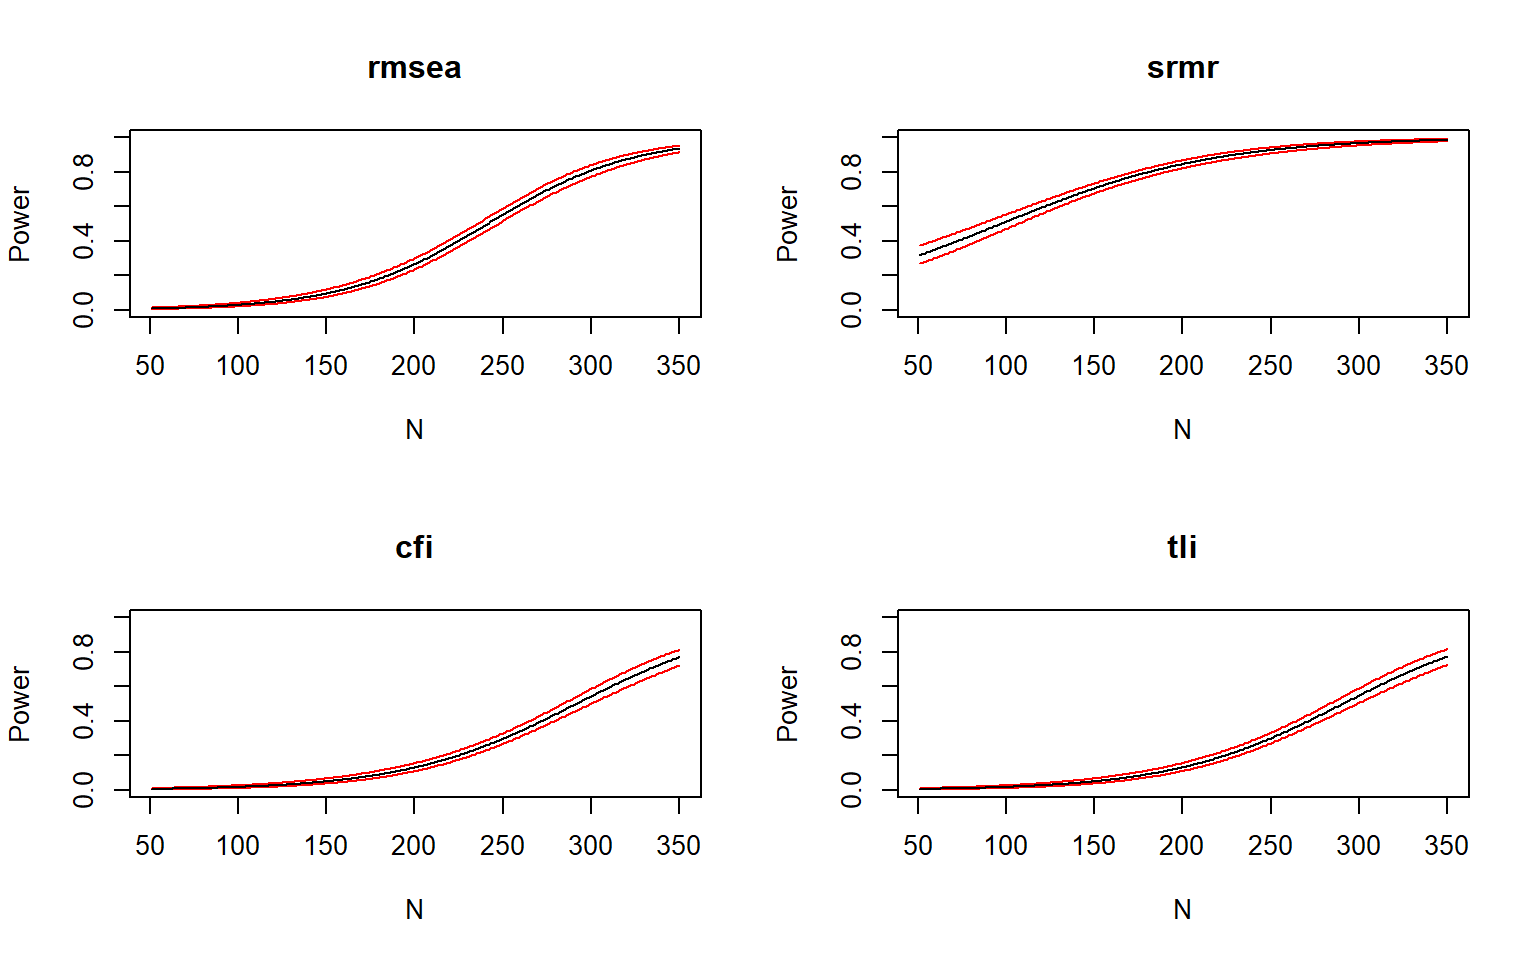
<figcaption>Figure 13: Power curves for fit indices under missing data conditions.</figcaption>
</figure>

``` python
plotPowerFit(
    h1model_miss,     # Data simulated under H1 (with cross-loadings)
    popmodel_miss,    # Data simulated under H0 (no cross-loadings)
    alpha = ALPHA,    # Significance level for determining power (see helpers.R)
    usedFit = FITS,   # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
    logistic = FALSE  # Display raw simulated points and cutoff lines instead of logistic curves
)
```

<figure id="fig-fit-curve-missing">
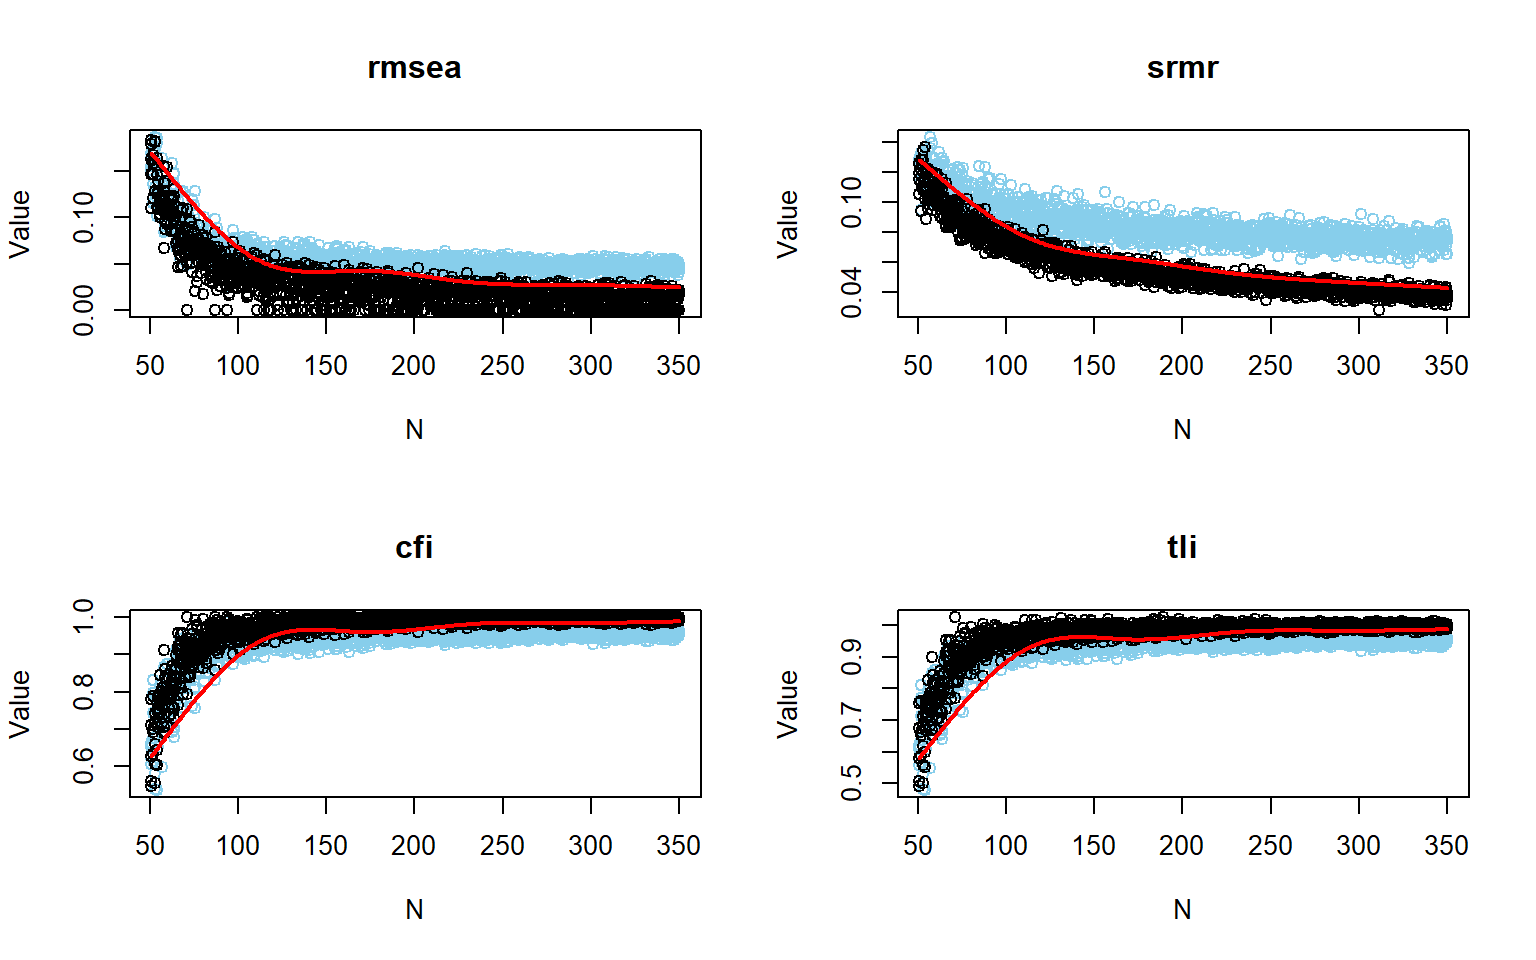
<figcaption>Figure 14: Power curves for fit indices under missing data conditions without logistic smoothing.</figcaption>
</figure>

Both figures show the expected pattern: power curves shift rightward relative to the ideal condition, requiring larger $N$ to reach the same thresholds. The separation between distributions in the raw fit-index plots is less pronounced, especially for CFI and TLI, which show more overlap at small and intermediate sample sizes.

``` python
# Estimate power for rejecting the misspecified model (h1model_miss)
# using fit-index cutoffs implied by the null model (popmodel_miss) at alpha = ALPHA and N = 359.
power_miss <- getPowerFit(
    h1model_miss,                 # Data simulated under H1 (with cross-loadings)
    nullObject = popmodel_miss,   # Data simulated under H0 (no cross-loadings)
    alpha = ALPHA,                # Significance level for determining power (see helpers.R)
    nVal = 359,                   # Sample size for analysis
    usedFit = FITS                # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Derive empirical cutoff values for the selected fit indices
# from the reference-model sampling distribution under the same conditions.
cutoff_miss <- getCutoff(
    popmodel_miss,                # Data simulated under H0 (no cross-loadings)
    alpha = ALPHA,                # Significance level for determining power (see helpers.R)
    nVal = 359,                   # Sample size for analysis
    usedFit = FITS                # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Combine power and cutoff values into a compact summary table.
power_cutoff_miss <- rbind(
    "Power" = as.numeric(power_miss),
    "Cutoff" = as.numeric(cutoff_miss[1, ])
)

# Standardize column names for presentation.
colnames(power_cutoff_miss) <- toupper(names(power_miss)) 

# Print the table.
knitr::kable(power_cutoff_miss, digits = 3, align = "c") 
```

|        | RMSEA | SRMR  |  CFI  |  TLI  |
|--------|:-----:|:-----:|:-----:|:-----:|
| Power  | 0.947 | 0.987 | 0.802 | 0.806 |
| Cutoff | 0.011 | 0.035 | 1.008 | 1.010 |

Table 12: Power and fit index cutoff values under missing data conditions at N = 359.

At $N = 359$, power was 0.947 for RMSEA, 0.987 for SRMR, 0.802 for CFI, and 0.806 for TLI. SRMR remains the strongest index and RMSEA is close behind; CFI and TLI are adequate but marginally so. The empirical cutoffs were 0.011 for RMSEA, 0.035 for SRMR, 1.008 for CFI, and 1.01 for TLI. The values above $1.00$ for CFI and TLI indicate that the classification boundary from the simulation falls at the upper edge of the index scale, which explains why their power is only marginally above $0.80$ at this $N$ ([McNeish & Wolf, 2021](#ref-mcneish2021)). Comparing $N = 231$ (ideal) with $N = 359$ (10% MCAR) makes the information cost of missing data concrete: approximately 128 additional participants are needed to restore the same level of detection performance.

### 5.2 Non-Normality

Mild departures from normality — skewness in the range $[-1, +1]$ and excess kurtosis in the range $[1, 2]$ — are common in applied social science measurement and can affect the behavior of fit indices even when robust estimators are used ([Irmer et al., 2024](#ref-irmer2024); [Kyriazos, 2018](#ref-kyriazos2018)). This analysis evaluates how such departures alter the power conclusions relative to the ideal condition.

``` python
plotPowerFit(
  h1model_nnorm,   # Data simulated under H1 (with cross-loadings)
  popmodel_nnorm,  # Data simulated under H0 (no cross-loadings)
  alpha = ALPHA,   # Significance level for determining power (see helpers.R)
  usedFit = FITS   # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)
```

<figure id="fig-power-curve-nnorm">
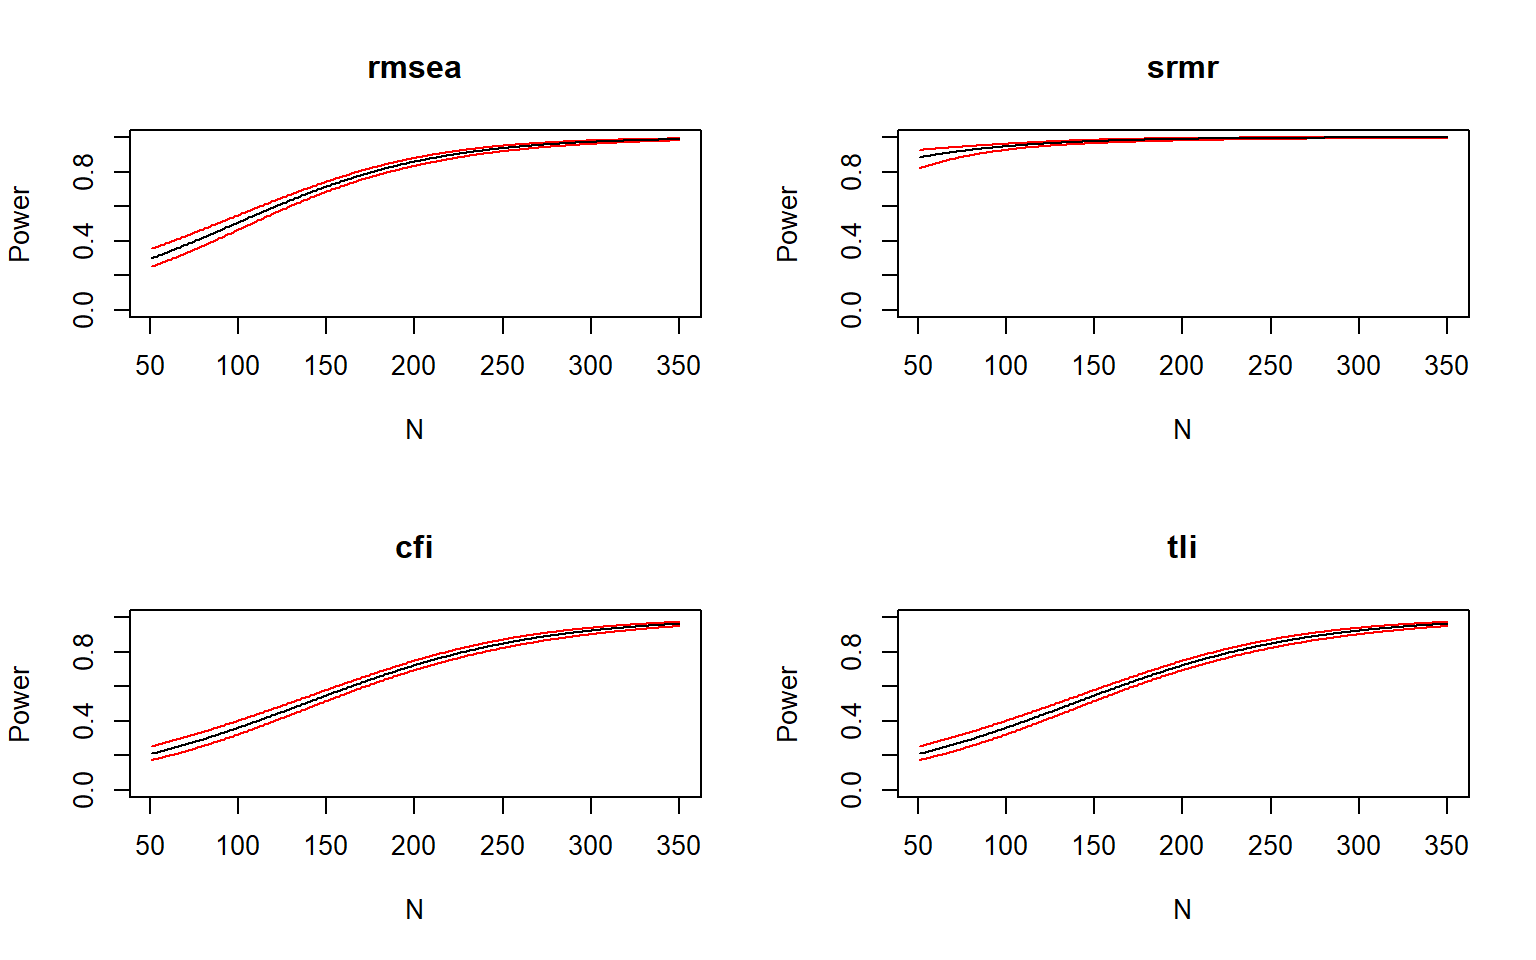
<figcaption>Figure 15: Power curves for fit indices under non-normal conditions.</figcaption>
</figure>

The ordering of sensitivity is stable: SRMR $>$ RMSEA $>$ CFI $\approx$ TLI. SRMR reaches near-ceiling power early in the sample-size range; RMSEA follows steadily; CFI and TLI rise more slowly and remain below the other two across most of the evaluated range.

``` python
plotPowerFit(
  h1model_nnorm,   # Data simulated under H1 (with cross-loadings)
  popmodel_nnorm,  # Data simulated under H0 (no cross-loadings)
  alpha = ALPHA,   # Significance level for determining power (see helpers.R)
  usedFit = FITS,  # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
  logistic = FALSE # Display raw simulated points and cutoff lines instead of logistic curves
)
```

<figure id="fig-fit-curve-nnorm">
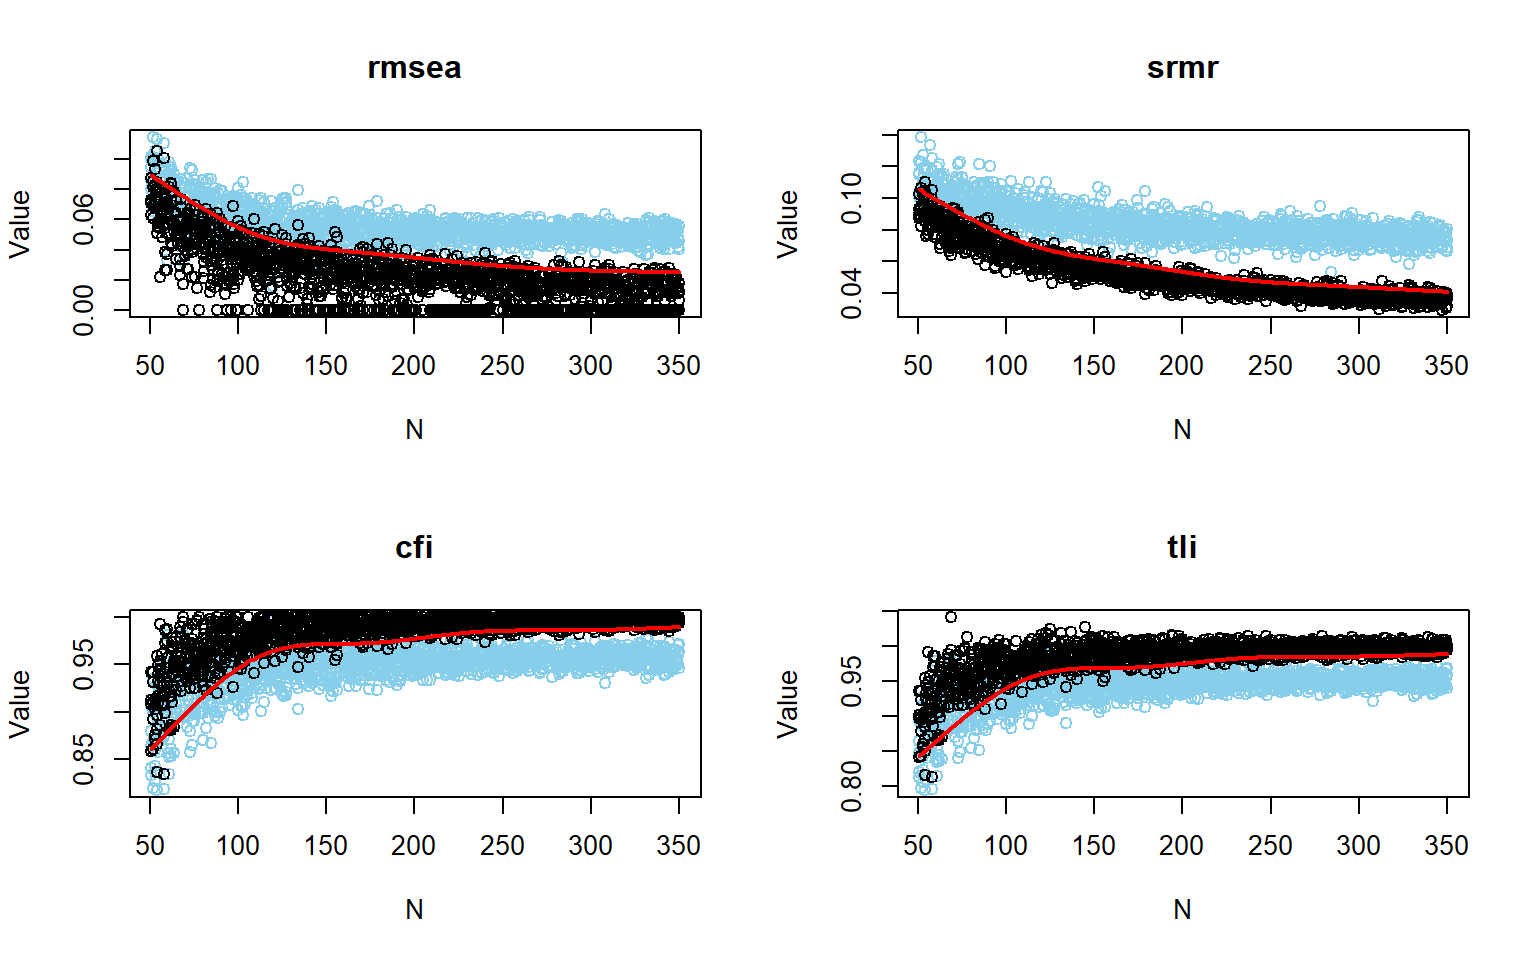
<figcaption>Figure 16: Power curves for fit indices under non-normal conditions without logistic smoothing.</figcaption>
</figure>

The raw fit-index plots confirm the ordering. For RMSEA and SRMR, the two point clouds are increasingly distinct as $N$ grows; for CFI and TLI, overlap is more visible at lower and intermediate sample sizes and clears only at larger $N$.

``` python
# Estimate power for rejecting the misspecified model (h1model_nnorm)
# using fit-index cutoffs implied by the null model (popmodel_nnorm) at alpha = ALPHA and N = 228.
power_nnorm <- getPowerFit(
  h1model_nnorm,               # Data simulated under H1 (with cross-loadings)
  nullObject = popmodel_nnorm, # Data simulated under H0 (no cross-loadings)
  alpha = ALPHA,               # Significance level for determining power (see helpers.R)
  nVal = 228,                  # Sample size for analysis
  usedFit = FITS               # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Derive empirical cutoff values for the selected fit indices
# from the null-model sampling distribution under the same conditions.
cutoff_nnorm <- getCutoff(
  popmodel_nnorm,              # Data simulated under H0 (no cross-loadings)
  alpha = ALPHA,               # Significance level for determining power (see helpers.R)
  nVal = 228,                  # Sample size for analysis
  usedFit = FITS               # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Combine power and cutoff values into a compact summary table.
power_cutoff_nnorm <- rbind(
  "Power" = as.numeric(power_nnorm),
  "Cutoff" = as.numeric(cutoff_nnorm[1, ])
)

# Standardize column names for presentation.
colnames(power_cutoff_nnorm) <- toupper(names(power_nnorm))

# Print the table.
knitr::kable(power_cutoff_nnorm, digits = 3, align = "c")
```

|        | RMSEA | SRMR  |  CFI  | TLI  |
|--------|:-----:|:-----:|:-----:|:----:|
| Power  | 0.91  | 0.994 | 0.800 | 0.80 |
| Cutoff | 0.04  | 0.059 | 0.964 | 0.96 |

Table 13: Power and fit index cutoff values under non-normal conditions at N = 228.

At $N = 228$, power was 0.91 for RMSEA, 0.994 for SRMR, 0.8 for CFI, and 0.8 for TLI. Notably, this result is almost identical to the ideal-condition estimate of $N = 231$, suggesting that mild non-normality introduces negligible additional cost under the current design and model structure ([Irmer et al., 2024](#ref-irmer2024)). The empirical cutoffs at $N = 228$ were 0.04 (RMSEA), 0.059 (SRMR), 0.964 (CFI), and 0.96 (TLI), consistent with the discrimination patterns in the figures.

### 5.3 Simulation with fixed N

Having established minimum sample size thresholds across individual analytical and simulation conditions — where requirements largely converged between $N = 100$ and $N = 231$ — the planning focus naturally shifts from searching for the smallest sufficient $N$ to evaluating a candidate recruitment target. In applied research, sample sizes are frequently shaped by budgetary, temporal, and logistical feasibility.

Fixing $N = 250$ represents a realistic, well-powered target sample size that comfortably exceeds both the ideal ($N = 231$) and non-normal ($N = 228$) benchmarks. This section subjects this planned sample size to a rigorous Monte Carlo stress test: evaluating 1,000 independent replications under compound realistic disturbances simultaneously (10% MCAR missing data and mild non-normality with robust MLR estimation). The goal is to determine whether a planned study with $N = 250$ reliably discriminates the true from the misspecified model under combined real-world imperfections.

This step also highlights the practical difference between empirical and traditional fit criteria. Empirical cutoffs are calibrated to the actual sampling distribution of the fitted model; traditional cutoffs are generic conventions. The two approaches can lead to very different conclusions about adequacy ([McNeish & Wolf, 2021](#ref-mcneish2021); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

``` python
plotPowerFit(
    h1model_fixed,    # Data simulated under H1 (with cross-loadings)
    popmodel_fixed,   # Data simulated under H0 (null model)
    alpha = ALPHA,    # Significance level for determining power (see helpers.R)
    usedFit = FITS    # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)
```

<figure id="fig-power-curve-fixed">
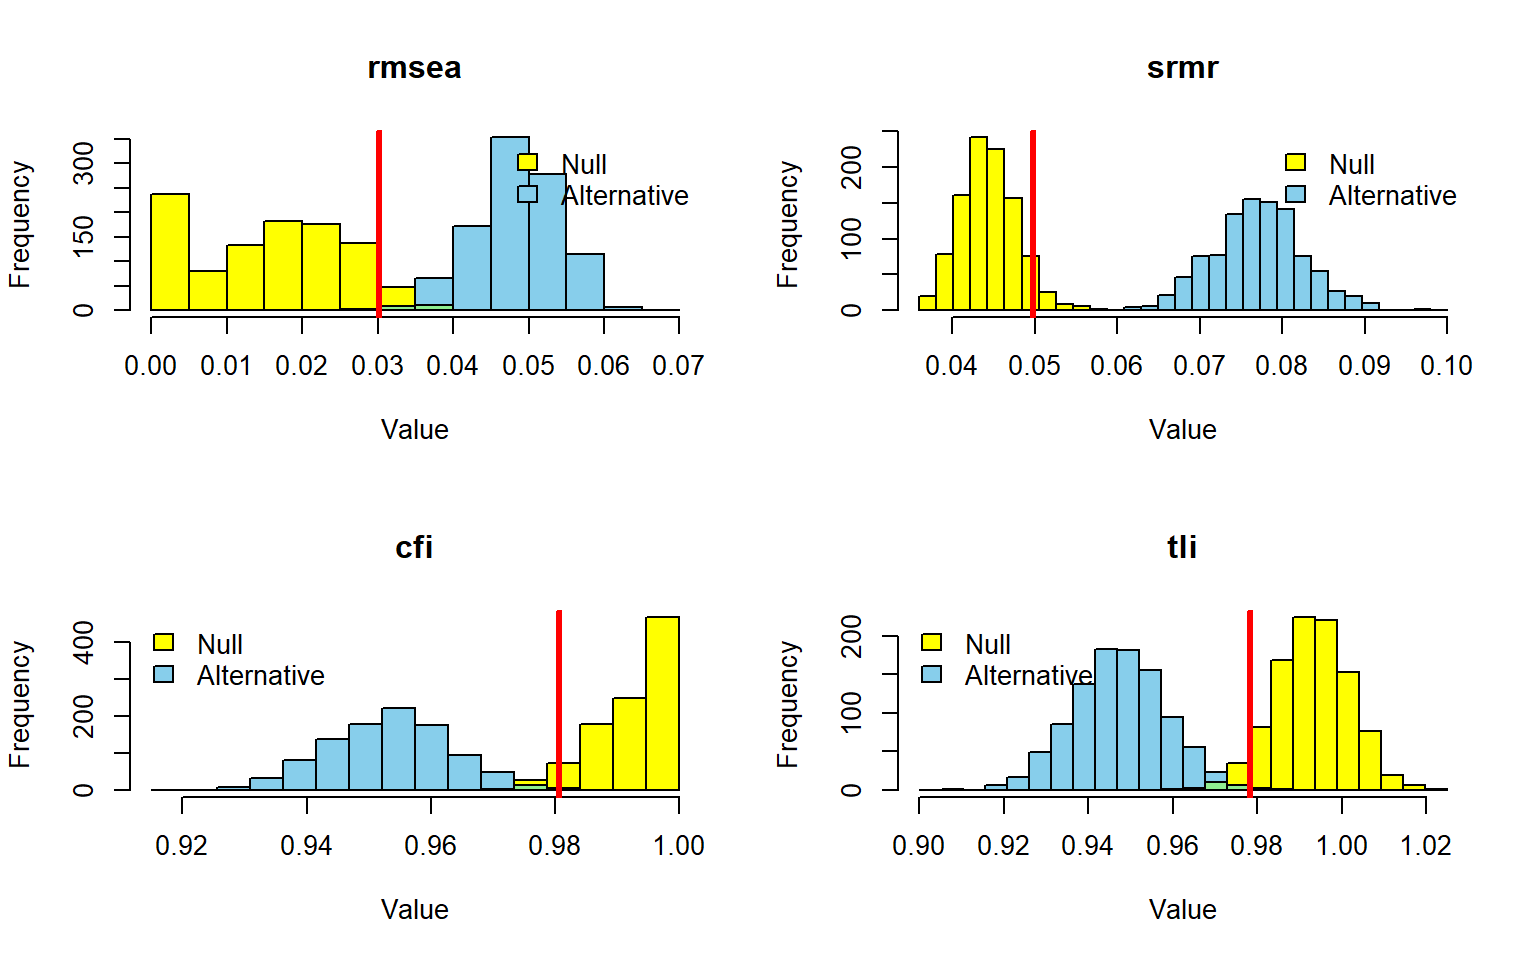
<figcaption>Figure 17: Power curves for fit indices with fixed sample size.</figcaption>
</figure>

With $N = 250$, the main analysis achieves power = 1.000 for all four fit indices using empirical cutoffs. The distributions of the reference and alternative conditions are completely separated in every panel, confirming that this sample size provides essentially perfect discrimination under the target design ([Liang & Sterba, 2024](#ref-liang2024); [Moshagen & Bader, 2024](#ref-moshagen2024)). The empirical cutoffs at $N = 250$ serve as data-driven benchmarks for this specific population-analysis model combination, and their values (<a href="#tbl-power-cutoff-fixed" class="quarto-xref">Table 14</a>) differ noticeably from conventional thresholds — which underscores the value of deriving rejection rules from the simulation rather than from generic recommendations.

``` python
# Estimate power for rejecting the misspecified model (h1model_fixed)
# using fit-index cutoffs implied by the null model.
power_fixed <- getPowerFit(
  h1model_fixed,                 # Data simulated under H1 (with cross-loadings)
  nullObject = popmodel_fixed,   # Data simulated under H0 (null model)
  alpha = ALPHA,                 # Significance level (see helpers.R)
  usedFit = FITS                 # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Derive empirical cutoff values for the selected fit indices
# from the null-model sampling distribution under the same conditions.
cutoff_fixed <- getCutoff(
  popmodel_fixed,     # Data simulated under H0 (null model)
  alpha = ALPHA,      # Significance level (see helpers.R)
  usedFit = FITS      # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Subset power to the four requested fit indices
power_fixed_clean <- power_fixed[FITS]
cutoff_fixed_clean <- cutoff_fixed[1, FITS]

# Combine power and cutoff values into a compact summary table.
power_cutoff_fixed <- rbind(
  "Power"  = as.numeric(power_fixed_clean),
  "Cutoff" = as.numeric(cutoff_fixed_clean)
)

# Standardize column names for presentation.
colnames(power_cutoff_fixed) <- toupper(FITS)

# Print the table.
knitr::kable(power_cutoff_fixed, digits = 3, align = "c")
```

|        | RMSEA | SRMR |  CFI  |  TLI  |
|--------|:-----:|:----:|:-----:|:-----:|
| Power  | 0.998 | 1.00 | 0.997 | 0.997 |
| Cutoff | 0.030 | 0.05 | 0.981 | 0.978 |

Table 14: Power and fit index cutoff values with fixed sample size.

#### 5.3.1 Power analysis with traditional cutoffs

Applying traditional rule-of-thumb thresholds to the same fixed-$N$ simulation produces a strikingly different picture. Power remains high for SRMR, falls substantially for CFI and TLI, and drops to zero for RMSEA — not because the sample is inadequate, but because the conventional $\text{RMSEA} \le 0.05$ threshold is misaligned with the empirical distribution of this specific model ([Kyriazos, 2018](#ref-kyriazos2018); [McNeish & Wolf, 2021](#ref-mcneish2021)). This contrast is one of the clearest illustrations in this tutorial of why power conclusions depend on how the rejection criterion is defined, not only on $N$.

``` python
plotPowerFit(
    h1model_fixed,           # Data simulated under H1 (with cross-loadings)
    popmodel_fixed,          # Data simulated under H0 (null model)
    cutoff = RULE_OF_THUMB,  # Traditional fit-index cutoffs (see helpers.R)
    alpha = ALPHA,           # Significance level (see helpers.R)
    usedFit = FITS           # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)
```

<figure id="fig-curve-fixed-traditional">
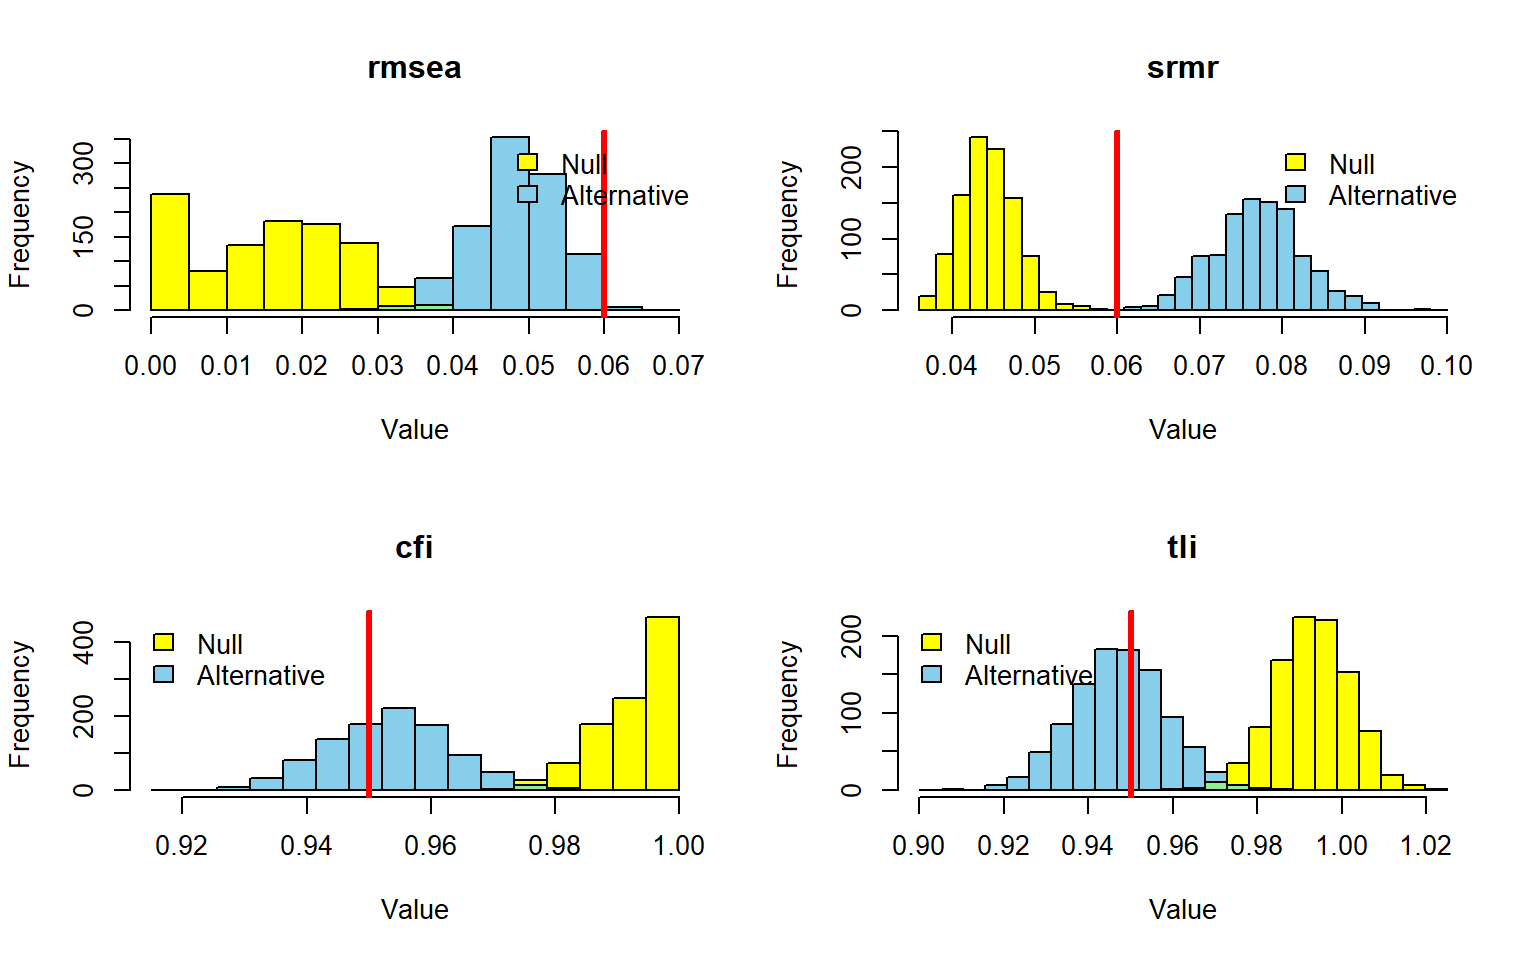
<figcaption>Figure 18: Power curves using traditional fit index cutoffs with fixed sample size.</figcaption>
</figure>

``` python
# Estimate power using traditional fit-index cutoffs.
power_traditional <- getPowerFit(
  h1model_fixed,     # Data simulated under H1 (with cross-loadings)
  RULE_OF_THUMB,     # Traditional fit-index cutoffs (see helpers.R)
  alpha = ALPHA,     # Significance level (see helpers.R)
  usedFit = FITS     # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Convert to a one-row table with column headers.
power_traditional_tbl <- t(as.data.frame(power_traditional))

# Standardize column names for presentation.
colnames(power_traditional_tbl) <- toupper(names(power_traditional))
rownames(power_traditional_tbl) <- "Power"

# Print the table.
knitr::kable(power_traditional_tbl, digits = 3, align = "c")
```

|       |  CFI  |  TLI  | RMSEA | SRMR  |
|-------|:-----:|:-----:|:-----:|:-----:|
| Power | 0.354 | 0.587 | 0.007 | 0.999 |

Table 15: Power for traditional fit index cutoffs with fixed sample size.

Taken together, the fixed-$N$ results support $N = 250$ as a conservative, stable design choice for the main comparison: it delivers perfect discrimination when empirical cutoffs are used, and its failures under traditional cutoffs reveal a limitation of those cutoffs rather than of the design itself ([Liang & Sterba, 2024](#ref-liang2024); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

## 6 Post Hoc Power Analysis

Post hoc power analysis evaluates the detection capacity of a study design after the data have been collected, using the observed $N$, the fitted model, and a specified reference structure. In SEM, this is meaningful only with respect to a clearly defined comparison: power is always the probability of rejecting a specific model under a specific alternative, not a general property of a dataset or a software routine ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)). In this section, we evaluate post hoc power against an empirical dataset from Mendeley ([Rogers, 2022](#ref-rogers2022)), fitting `analyzemodel` to real WHOQOL-BREF data and assessing how reliably the collected $N$ would have rejected meaningful misspecification.

### 6.1 With Simulation

The simulation-based strategy first fits the analysis model to the real data to obtain an empirically grounded reference structure. It then generates data from both the null model and the alternative model at the observed $N$ and quantifies how well the fit indices separate the two conditions. This approach is particularly informative when the effect of interest is defined in model terms, because the full parameterization — loadings, residual structure, latent correlations — shapes the discrepancy and therefore the power estimate ([Feng & Hancock, 2023](#ref-feng2023); [Wang & Rhemtulla, 2021](#ref-wang2021)).

``` python
plotPowerFit(
    h1model_alt,                  # Data simulated under H1 (with cross-loadings)
    nullObject = realmodel_null,  # Data simulated under H0 (no cross-loadings)
    alpha      = ALPHA,           # Significance level (see helpers.R)
    usedFit    = FITS             # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)
```

<figure id="fig-posthoc-plotpower">
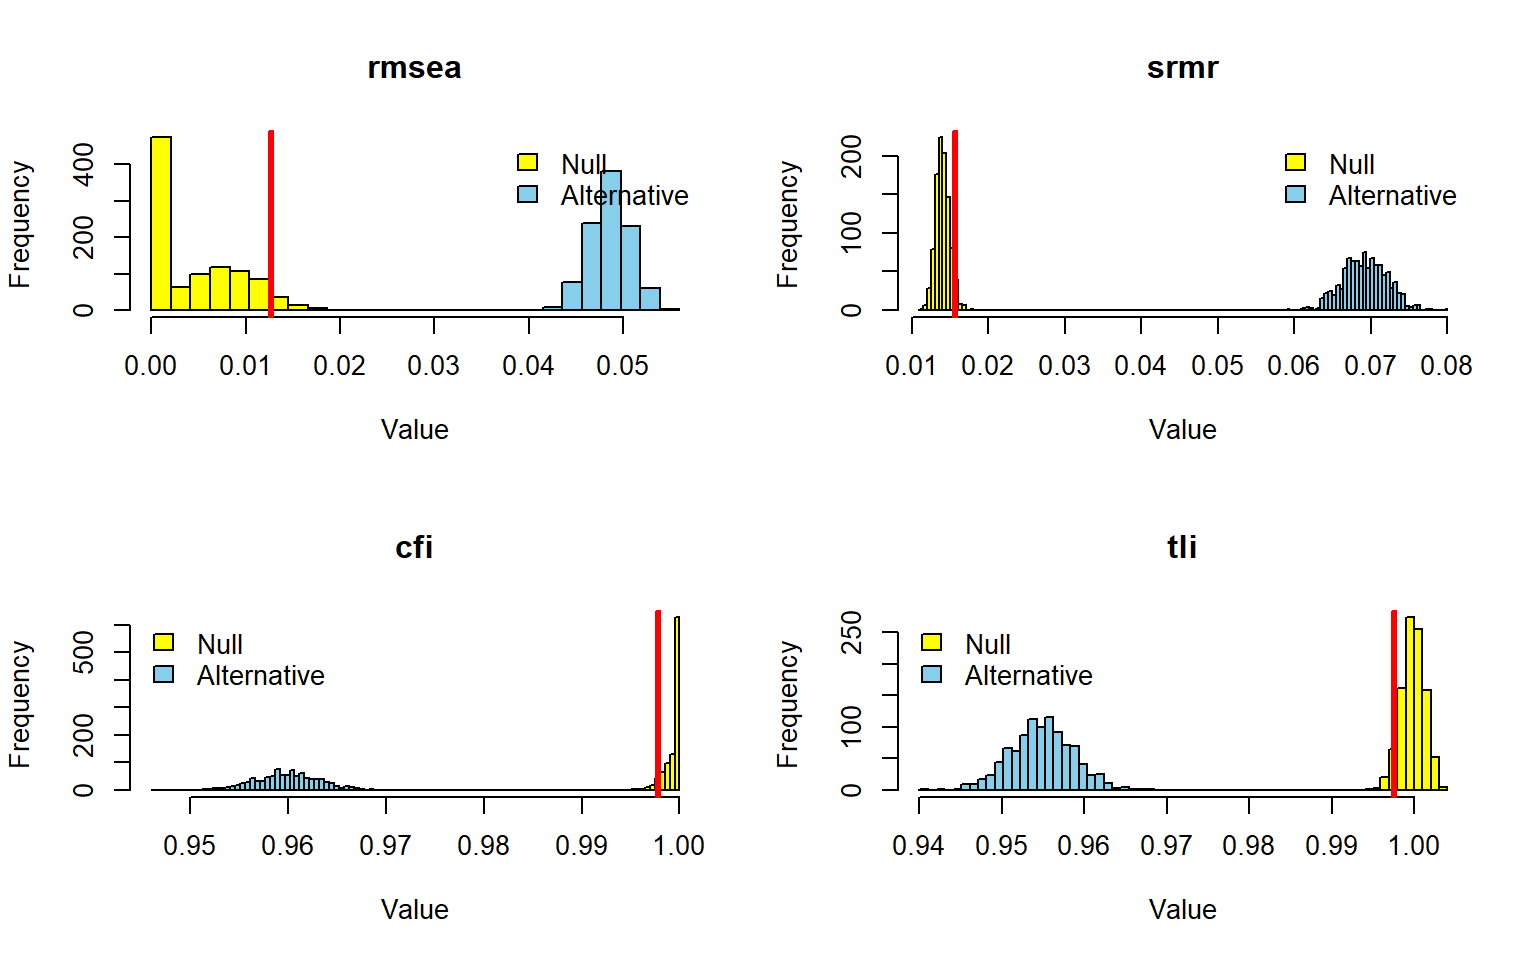
<figcaption>Figure 19: Power curve for post hoc analysis based on simulation.</figcaption>
</figure>

``` python
# Estimate power for rejecting the misspecified model (h1model_alt)
# using fit-index cutoffs implied by the null model.
posthoc_pow <- getPowerFit(
    h1model_alt,                 # Data simulated under H1 (with cross-loadings)
    nullObject = realmodel_null, # Data simulated under H0 (no cross-loadings)
    alpha      = ALPHA,          # Significance level (see helpers.R)
    usedFit    = FITS            # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Subset power to the four requested fit indices
posthoc_pow_clean <- posthoc_pow[FITS]

# Return power values as a table
knitr::kable(
  as.data.frame(t(as.numeric(posthoc_pow_clean))),
  col.names = toupper(FITS),
  digits = 3,
  align = "c"
)
```

| RMSEA | SRMR | CFI | TLI |
|:-----:|:----:|:---:|:---:|
|   1   |  1   |  1  |  1  |

Table 16: Power for post hoc analysis based on simulation.

All four fit indices reached power equal to $1.00$. In the figure, every panel shows complete separation between the null and alternative distributions, with the red cutoff line falling cleanly between them and no visible overlap. For RMSEA, the null distribution concentrates near zero while the alternative is centered around $0.05$. For SRMR, the null clusters near $0.01$–$0.02$ and the alternative near $0.06$–$0.08$. For CFI and TLI, the null is close to $1.00$ and the alternative centers around $0.95$–$0.97$. The complete discrimination in every panel confirms that the observed $N$ would have been fully adequate to detect the target misspecification ([Pornprasertmanit et al., 2021](#ref-simsem2021)). Note that some indices are operating below their conventional thresholds, which is a consequence of the empirical cutoffs derived from the null distribution in this specific setting — not an indication that model fit is poor.

### 6.2 With Analytical Solutions

Analytical post hoc power expresses the effect through $F_0$ or RMSEA and links it to the noncentrality-based framework of the likelihood-ratio test. This is computationally immediate and free from Monte Carlo sampling error, making it the preferred first-pass approach when the asymptotic assumptions underlying the chi-square test are credible ([Jak et al., 2021](#ref-jak2021); [Moshagen & Bader, 2024](#ref-moshagen2024)). Two specifications are compared here, illustrating a spectrum from the most generic to the most substantively specific formulation.

#### 6.2.1 Model-free specification

The first specification supplies $\text{RMSEA} = 0.05$ directly, treating misspecification as a generic level of global misfit per degree of freedom. This makes the analysis comparable across SEM families sharing the same $df$, but it abstracts away from the particular covariance structure of the WHOQOL-BREF model ([Jak et al., 2021](#ref-jak2021); [MacCallum et al., 1996](#ref-maccallum1996)).

``` python
# Formatted table extracting analytical post hoc power metrics for clean manuscript embedding
table_sempower(ph_rmsea) # See function definition in helpers.R
```

| Metric                                  |         Symbol         |     Value |
|:-----------------------------------|:----------------------:|----------:|
| Population discrepancy                  |         $F_0$          |     0.613 |
| Root mean square error of approximation |     $\text{RMSEA}$     |     0.050 |
| McDonald centrality index               |          $Mc$          |     0.736 |
| Goodness-of-fit index                   |      $\text{GFI}$      |     0.951 |
| Adjusted goodness-of-fit index          |     $\text{AGFI}$      |     0.941 |
| Degrees of freedom                      |          $df$          |       245 |
| Observed sample size                    |          $N$           |      1047 |
| Critical chi-square                     | $\chi^2_{\text{crit}}$ |   282.511 |
| Noncentrality parameter                 |       $\lambda$        |   640.675 |
| Significance level (alpha)              |        $\alpha$        |     0.050 |
| Type II error rate (beta)               |        $\beta$         |  3.07e-47 |
| Statistical power                       |      $1 - \beta$       | \> 0.9999 |

Table 17: Analytical post hoc power parameters for RMSEA = 0.05

The post hoc power parameters in <a href="#tbl-posthoc-rmsea" class="quarto-xref">Table 17</a> demonstrate that with $F_0$ = 0.613, $\text{RMSEA}$ = 0.05, $df$ = 245, and $N$ = 1047, the noncentrality parameter reached $\text{NCP}$ = 640.675, far exceeding the critical value $\chi^2_{\text{crit}}$ = 282.511. Power was effectively 1. As illustrated in <a href="#fig-posthoc-rmsea" class="quarto-xref">Figure 20</a>, the noncentral $\chi^2$ curve lies far to the right of the critical value, and the shaded $\beta$ region is negligible ([Jobst et al., 2023](#ref-jobst2023); [MacCallum et al., 1996](#ref-maccallum1996)).

``` python
# Isolated chi-square distribution plot for clean manuscript embedding
plot_sempower(ph_rmsea) # See function definition in helpers.R
```

<figure id="fig-posthoc-rmsea">
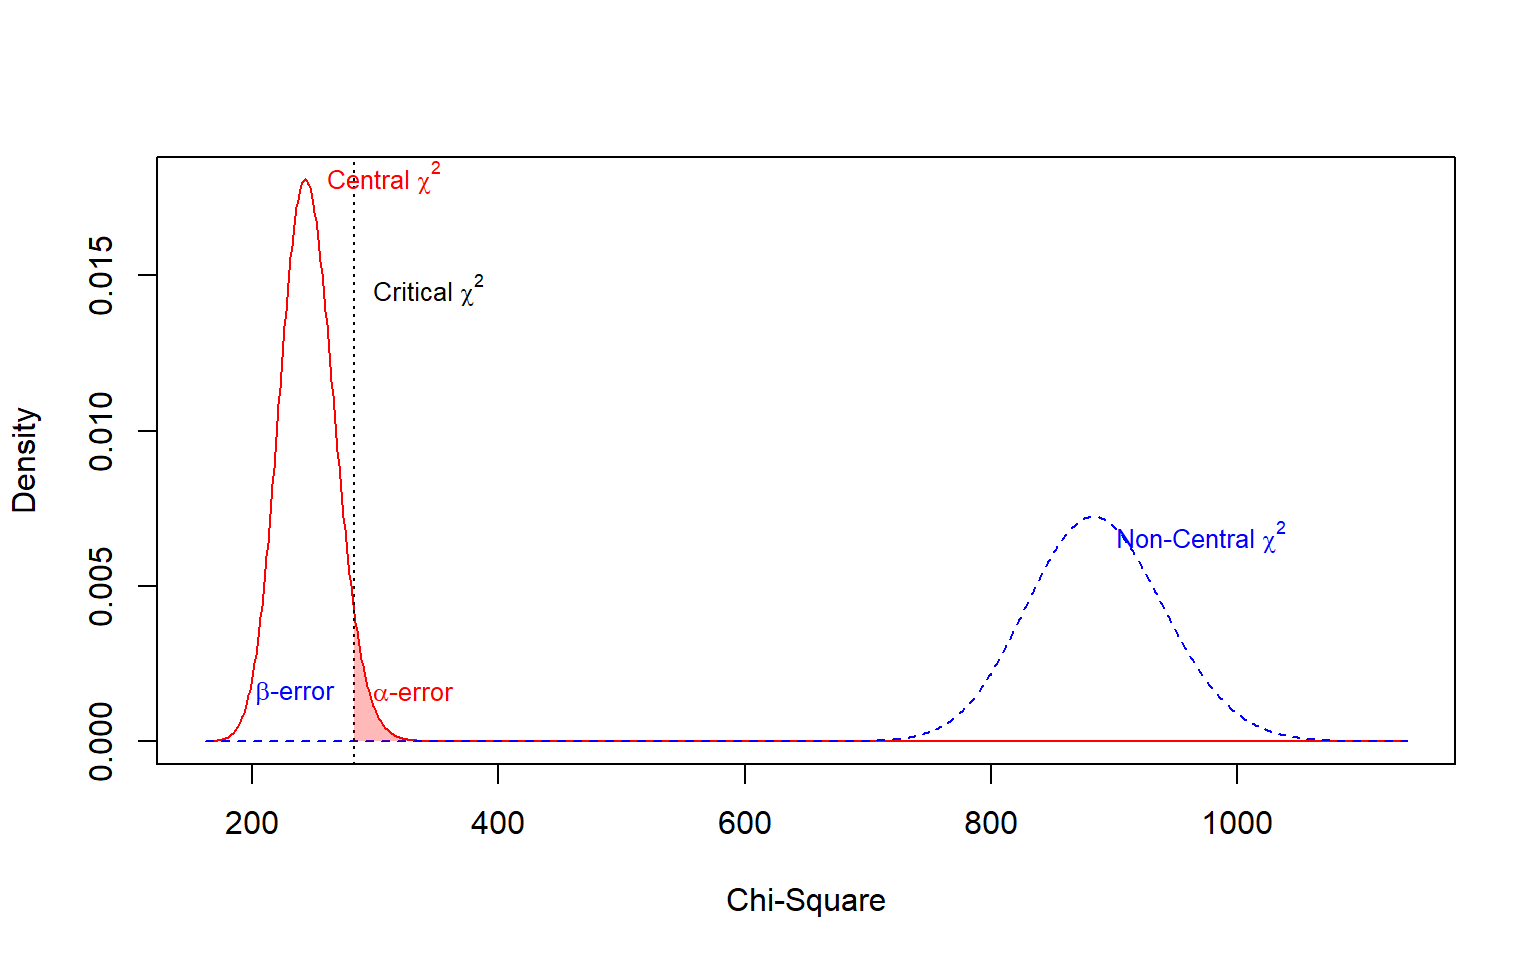
<figcaption>Figure 20: Post hoc power analysis for RMSEA = 0.05.</figcaption>
</figure>

#### 6.2.2 Model-based specification: global fit

The second specification derives the effect from the discrepancy between `h1model` (incorporating the cross-loadings) and the fitted analysis model, evaluating the null model against the saturated model. This tests global fit rather than an isolated restriction, so it is sensitive to any source of misspecification in the analysis model, not only the cross-loadings ([Moshagen & Bader, 2024](#ref-moshagen2024); [Wang, 2023](#ref-wang2023)).

``` python
# Formatted table extracting empirical model-based post hoc metrics for clean manuscript embedding
table_sempower(ph_realmodel) # See function definition in helpers.R
```

| Metric                                  |         Symbol         |     Value |
|:-----------------------------------|:----------------------:|----------:|
| Population discrepancy                  |         $F_0$          |     0.579 |
| Root mean square error of approximation |     $\text{RMSEA}$     |     0.049 |
| McDonald centrality index               |          $Mc$          |     0.749 |
| Goodness-of-fit index                   |      $\text{GFI}$      |     0.954 |
| Adjusted goodness-of-fit index          |     $\text{AGFI}$      |     0.944 |
| Standardized root mean square residual  |     $\text{SRMR}$      |     0.067 |
| Comparative fit index                   |      $\text{CFI}$      |     0.960 |
| Degrees of freedom                      |          $df$          |       245 |
| Observed sample size                    |          $N$           |      1047 |
| Critical chi-square                     | $\chi^2_{\text{crit}}$ |   282.511 |
| Noncentrality parameter                 |       $\lambda$        |   605.611 |
| Significance level (alpha)              |        $\alpha$        |     0.050 |
| Type II error rate (beta)               |        $\beta$         |  1.87e-43 |
| Statistical power                       |      $1 - \beta$       | \> 0.9999 |

Table 18: Analytical post hoc power parameters for empirical fitted model

With $F_0$ = 0.579, $\text{RMSEA}$ = 0.049, $df$ = 245, and $N$ = 1047, the noncentrality reached $\text{NCP}$ = 605.611 against a critical value of $\chi^2_{\text{crit}}$ = 282.511. Power was 1, confirming that the observed sample size provides complete statistical power to detect the misspecification (<a href="#tbl-posthoc-realmodel" class="quarto-xref">Table 18</a>; <a href="#fig-posthoc-realmodel" class="quarto-xref">Figure 21</a>).

``` python
# Isolated chi-square distribution plot for clean manuscript embedding
plot_sempower(ph_realmodel) # See function definition in helpers.R
```

<figure id="fig-posthoc-realmodel">
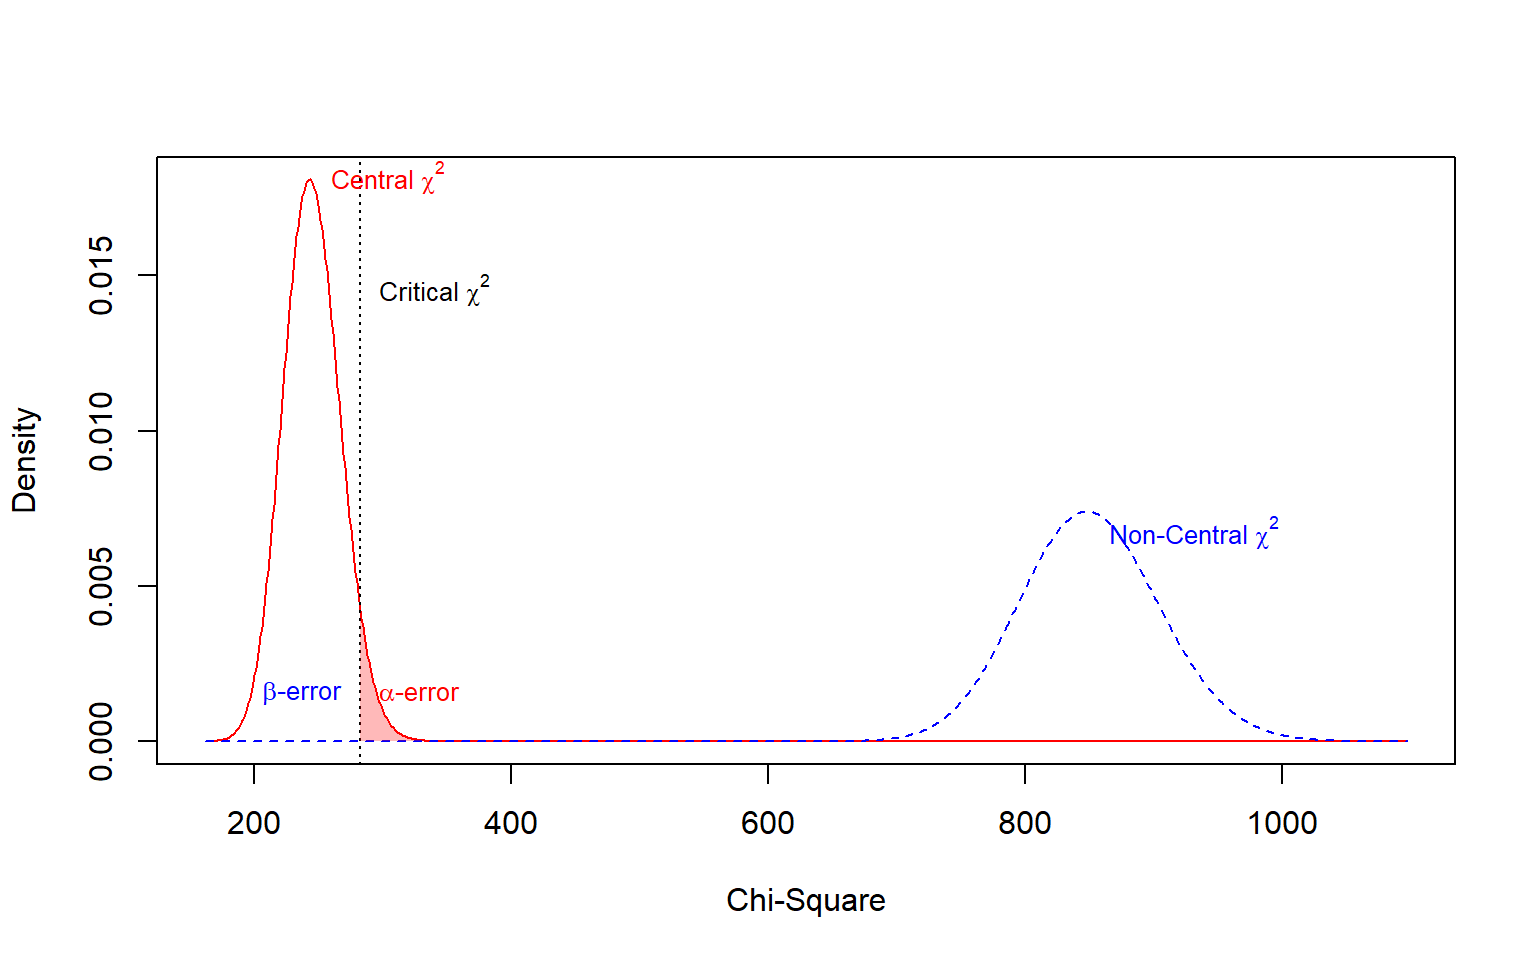
<figcaption>Figure 21: Post hoc power analysis for the real model.</figcaption>
</figure>

However, post hoc power must always be interpreted with methodological caution. Calculating power retrospectively from observed sample statistics after finding a non-significant result constitutes the well-known “observed power fallacy” ([Jobst et al., 2023](#ref-jobst2023); [MacCallum et al., 1996](#ref-maccallum1996); [Zhang & Yuan, 2018](#ref-zhang2018)), where low power is simply a tautological re-expression of an unremarkable $p$-value. Post hoc power analysis remains legitimate only when framed prospective-retrospectively: asking whether the collected $N$ possessed adequate sensitivity to reject a pre-specified, theoretically grounded alternative ($H_1$) that was determined prior to inspecting data-derived effects ([Moshagen & Bader, 2024](#ref-moshagen2024); [Wang, 2023](#ref-wang2023)).

## References

Aguirre-Urreta, M. I., Rönkkö, M., & McIntosh, C. N. (2024). Too Small to Succeed: Small Samples and the p-Value Problem. *SIGMIS Database*, *55*(3), 12–49. <https://doi.org/10.1145/3685235.3685238>

Buchberger, E. S., Ngo, C. T., Peikert, A., Brandmaier, A. M., & Werkle-Bergner, M. (2024). Estimating statistical power for structural equation models in developmental cognitive science: A tutorial in R. *Behavior Research Methods*, *56*(7), 1–18. <https://doi.org/10.3758/s13428-024-02396-2>

Feng, Y., & Hancock, G. R. (2023). Power Analysis within a Structural Equation Modeling Framework. In R. H. Hoyle (Ed.), *Handbook of Structural Equation Modeling*. The Guilford Press.

Irmer, J. P., Klein, A. G., & Schermelleh-Engel, K. (2024). Model-implied simulation-based power estimation for correctly specified and distributionally misspecified models: Applications to nonlinear and linear structural equation models. *Behavior Research Methods*, *56*(8), 8955–8991. <https://doi.org/10.3758/s13428-024-02507-z>

Jak, S., Jorgensen, T. D., Verdam, M. G. E., Oort, F. J., & Elffers, L. (2021). Analytical power calculations for structural equation modeling: A tutorial and Shiny app. *Behavior Research Mehods*, *53*, 1385–1406. <https://doi.org/10.3758/s13428-020-01479-0/Published>

Jobst, L. J., Bader, M., & Moshagen, M. (2023). A tutorial on assessing statistical power and determining sample size for structural equation models. *Psychological Methods*, *28*(1), 207–221. <https://doi.org/10.1037/met0000423>

Kyriazos, T. A. (2018). Applied Psychometrics: Sample Size and Sample Power Considerations in Factor Analysis (EFA, CFA) and SEM in General. *Psychology*, *09*(08), 2207–2230. <https://doi.org/10.4236/psych.2018.98126>

Liang, A., & Sterba, S. K. (2024). Power analysis to detect misfit in SEMs with many items: Resolving unrecognized problems, relating old and new approaches, and “matching” power analysis approach to data analysis approach. *Psychological Methods*. <https://doi.org/10.1037/met0000684>

Lin, L.-C., & Yao, G. (2022). Validation of the factor structure of the WHOQOL-BREF using meta-analysis of exploratory factor analysis and social network analysis. *Psychological Assessment*, *34*(7), 660–670. <https://doi.org/10.1037/pas0001122>

MacCallum, R. C., Browne, M. W., & Sugawara, H. M. (1996). Power analysis and determination of sample size for covariance structure modeling. *Psychological Methods*, *1*(2), 130–149. <https://doi.org/10.1037/1082-989X.1.2.130>

McNeish, D., & Wolf, M. G. (2021). Dynamic fit index cutoffs for confirmatory factor analysis models. *Psychological Methods*, *28*(1), 61–88. <https://doi.org/10.1037/met0000425>

Moshagen, M., & Bader, M. (2024). <span class="nocase">semPower</span>: General power analysis for structural equation models. *Behavior Research Methods*, *56*(4), 2901–2922. <https://doi.org/10.3758/s13428-023-02254-7>

<span class="nocase">Mosqueira Taipe, C. M., Amador Campos, J. A., Krieger, V., Miasso, A. I., Molina, N. P. F. M., & dos Santos, P. L.</span> (2026). Systematic review of the factor structure of <span class="nocase">WHOQOL-bref</span> in adult population. *Quality of Life Research*, *35*(17), 1–18. <https://doi.org/10.1007/s11136-025-04115-6>

Muthén, L. K., & Muthén, B. O. (2002). How to Use a Monte Carlo Study to Decide on Sample Size and Determine Power. *Structural Equation Modeling: A Multidisciplinary Journal*, *9*(4), 599–620. <https://doi.org/10.1207/S15328007SEM0904_8>

Pornprasertmanit, S., Miller, P., Schoemann, A., & Jorgensen, T. D. (2021). *Simsem: SIMulated Structural Equation Modeling*. <https://CRAN.R-project.org/package=simsem>

Rogers, P. (2022). Best Practices for Your Exploratory Factor Analysis: A Factor Tutorial. *Revista de Administração Contemporânea*, *26*(6). <https://doi.org/10.1590/1982-7849rac2022210085.en>

Schoemann, A. M., Miller, P., Pornprasertmanit, S., & Wu, W. (2014). Using Monte Carlo simulations to determine power and sample size for planned missing designs. *International Journal of Behavioral Development*, *38*(5), 471–479. <https://doi.org/10.1177/0165025413515169>

Wang, Y. A. (2023). *How to Conduct Power Analysis for Structural Equation Models: A Practical Primer* \[Preprint\]. PsyArXiv. <https://doi.org/10.31234/osf.io/4n3uk>

Wang, Y. A., & Rhemtulla, M. (2021). Power Analysis for Parameter Estimation in Structural Equation Modeling: A Discussion and Tutorial. *Advances in Methods and Practices in Psychological Science*, *4*(1), 1–17. <https://doi.org/10.1177/2515245920918253>

Wolf, E. J., Harrington, K. M., Clark, S. L., & Miller, M. W. (2013). Sample Size Requirements for Structural Equation Models: An Evaluation of Power, Bias, and Solution Propriety. *Educational and Psychological Measurement*, *76*(6), 913–934. <https://doi.org/10.1177/0013164413495237>

Zhang, Z., & Yuan, K.-H. (2018). *Practical statistical power analysis using Webpower and R*. ISDSA Press.